# Phase 1: Data Ingestion & Architecture.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ssvep_data.zip to ssvep_data (1).zip


In [ ]:
from pathlib import Path
import zipfile

zip_path = Path("ssvep_data (1).zip")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(".")

print("Extracted files:")
print(list(Path(".").glob("**/*.csv"))[:5])
print(list(Path(".").glob("**/*.xlsx")))

Extracted files:
[PosixPath('BCI-SSVEP_Database_Aceves/A009SV1_2.csv'), PosixPath('BCI-SSVEP_Database_Aceves/A013SV1_1.csv'), PosixPath('BCI-SSVEP_Database_Aceves/A029SB3_1.csv'), PosixPath('BCI-SSVEP_Database_Aceves/A004SB2_1.csv'), PosixPath('BCI-SSVEP_Database_Aceves/A002SB2_1.csv')]
[PosixPath('BCI-SSVEP_Database_Aceves/Signal Database.xlsx')]


In [ ]:
from pathlib import Path
csv_files = list(Path(".").glob("**/*.csv"))
xlsx_files = list(Path(".").glob("**/*.xlsx"))

print(f"CSV files found: {len(csv_files)}")
print(f"Excel files found: {len(xlsx_files)}")

print("\nExcel file:")
print(xlsx_files[0])

print("\nFirst 10 CSV files:")
for file in csv_files[:10]:
    print(file)


CSV files found: 146
Excel files found: 1

Excel file:
BCI-SSVEP_Database_Aceves/Signal Database.xlsx

First 10 CSV files:
BCI-SSVEP_Database_Aceves/A009SV1_2.csv
BCI-SSVEP_Database_Aceves/A013SV1_1.csv
BCI-SSVEP_Database_Aceves/A029SB3_1.csv
BCI-SSVEP_Database_Aceves/A004SB2_1.csv
BCI-SSVEP_Database_Aceves/A002SB2_1.csv
BCI-SSVEP_Database_Aceves/A012SB2_1.csv
BCI-SSVEP_Database_Aceves/A030SB1_1.csv
BCI-SSVEP_Database_Aceves/A008SB3_1.csv
BCI-SSVEP_Database_Aceves/A010SV1_1.csv
BCI-SSVEP_Database_Aceves/A022SB2_1.csv


In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("BCI-SSVEP_Database_Aceves")
METADATA_FILE = DATA_DIR / "Signal Database.xlsx"
OUTPUT_FILE = Path("Master_EEG_Dataset.csv")
print("Step 1: Loading clinical metadata...")
meta_df = pd.read_excel(METADATA_FILE, sheet_name="Hoja1", header=1)
meta_df = meta_df.dropna(subset=["SESSION DATA"]).copy()
print(f"Metadata loaded successfully. Found {len(meta_df)} session records.")
print("\nMetadata columns:")
print(meta_df.columns.tolist())

eeg_columns = [
    "Counter",
    "Interpolated",
    "AF3",
    "F7",
    "F3",
    "FC5",
    "T7",
    "P7",
    "O1",
    "O2",
    "P8",
    "T8",
    "FC6",
    "F4",
    "F8",
    "AF4",
]

required_metadata_columns = [
    "SESSION DATA",
    "AGE",
    "GENDER",
    "TEST NAME",
    "TEST TYPE",
    "STEADY-STATE TIME (s)",
]

missing_metadata_columns = [
    col for col in required_metadata_columns if col not in meta_df.columns
]

if missing_metadata_columns:
    raise ValueError(f"Missing required metadata columns: {missing_metadata_columns}")

all_sessions_data = []
missing_files = []
failed_files = []

print("\nStep 2: Starting the data fusion loop...")

for _, row in meta_df.iterrows():
    session_name = str(row["SESSION DATA"]).strip()
    csv_name = Path(session_name).with_suffix(".csv").name
    csv_path = DATA_DIR / csv_name

    subject_id = csv_path.stem[:4]

    if not csv_path.exists():
        missing_files.append(csv_name)
        continue

    try:
        eeg_df = pd.read_csv(csv_path, skiprows=1, header=None)

        if eeg_df.shape[1] != len(eeg_columns):
            failed_files.append(
                {
                    "file": csv_name,
                    "reason": f"Expected 16 columns, found {eeg_df.shape[1]}",
                }
            )
            continue

        eeg_df.columns = eeg_columns
        eeg_df = eeg_df.drop(columns=["Interpolated"])

        eeg_df["Session_ID"] = csv_path.stem
        eeg_df["Subject_ID"] = subject_id
        eeg_df["Age"] = row["AGE"]
        eeg_df["Gender"] = row["GENDER"]
        eeg_df["Test_Type"] = row["TEST TYPE"]
        eeg_df["Test_Name"] = row["TEST NAME"]
        eeg_df["Steady_State_Time"] = row["STEADY-STATE TIME (s)"]

        all_sessions_data.append(eeg_df)

        print(f"Merged: {csv_name} | Subject: {subject_id} | Shape: {eeg_df.shape}")

    except Exception as exc:
        failed_files.append(
            {
                "file": csv_name,
                "reason": str(exc),
            }
        )

print("\nStep 3: Concatenating the master dataset...")

if not all_sessions_data:
    raise FileNotFoundError(
        "No EEG CSV files were successfully processed. Check DATA_DIR and file names."
    )

master_df = pd.concat(all_sessions_data, ignore_index=True)

print("\n--- FUSION COMPLETE ---")
print(f"Total master dataset shape: {master_df.shape}")

print("\nPreview:")
display(master_df.head())

master_df.to_csv(OUTPUT_FILE, index=False)
print(f"\nSaved master dataset to: {OUTPUT_FILE}")

if missing_files:
    print(f"\nWarning: {len(missing_files)} files were listed in Excel but not found.")
    print(missing_files[:20])

if failed_files:
    print(f"\nWarning: {len(failed_files)} files could not be processed.")
    display(pd.DataFrame(failed_files))


Step 1: Loading clinical metadata...
Metadata loaded successfully. Found 141 session records.

Metadata columns:
['Unnamed: 0', 'GROUP', 'GENDER', 'AGE', 'RIGHT HANDED?', 'HEALTHY*', 'GLASSES', 'SMOKER', 'MEDICAL TREATMENT', 'MEDICINE / SUPPLEMENTS', 'TRANSFER RATE', 'TEST TYPE', 'TEST NAME', 'NUMBER OF EVENTS', 'EVENT DURATION (ms)', 'SESSION DATA', 'STEADY-STATE TIME (s)', 'TEST DURATION  (s)']

Step 2: Starting the data fusion loop...
Merged: A001SV1_1.csv | Subject: A001 | Shape: (12288, 22)
Merged: A001SB1_1.csv | Subject: A001 | Shape: (2944, 22)
Merged: A001SM1_1.csv | Subject: A001 | Shape: (5888, 22)
Merged: A002SB1_1.csv | Subject: A002 | Shape: (9216, 22)
Merged: A002SB2_1.csv | Subject: A002 | Shape: (9600, 22)
Merged: A002SB3_1.csv | Subject: A002 | Shape: (9600, 22)
Merged: A002SM1_1.csv | Subject: A002 | Shape: (7552, 22)
Merged: A002SV1_1.csv | Subject: A002 | Shape: (11392, 22)
Merged: A003SB1_1.csv | Subject: A003 | Shape: (9216, 22)
Merged: A003SB2_1.csv | Subject: A

,Counter,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,...,F4,F8,AF4,Session_ID,Subject_ID,Age,Gender,Test_Type,Test_Name,Steady_State_Time
0,97.0,4219.487076,4119.487079,4217.435794,4106.666566,4228.205025,4218.461435,4212.307589,4154.871693,4213.846051,...,4242.563999,4222.563999,4221.538358,A001SV1_1,A001,48.0,MALE,VISUAL,IMAGE SEARCH,5.0
1,98.0,4211.794769,4113.846053,4211.281948,4113.846053,4234.358871,4215.384512,4204.102461,4151.794770,4213.846051,...,4227.179384,4214.358871,4208.717846,A001SV1_1,A001,48.0,MALE,VISUAL,IMAGE SEARCH,5.0
2,99.0,4222.051179,4125.128104,4211.281948,4120.512720,4237.948614,4214.358871,4205.640923,4152.307591,4215.384512,...,4228.717845,4221.025538,4213.846051,A001SV1_1,A001,48.0,MALE,VISUAL,IMAGE SEARCH,5.0
3,100.0,4231.794768,4135.384514,4218.461435,4121.538361,4217.948615,4216.922974,4214.871692,4156.922975,4216.410153,...,4239.999896,4226.666563,4223.589640,A001SV1_1,A001,48.0,MALE,VISUAL,IMAGE SEARCH,5.0
4,101.0,4221.538358,4132.820412,4214.358871,4124.102463,4216.922974,4217.948615,4217.435794,4158.461437,4216.922974,...,4235.384512,4222.051179,4214.871692,A001SV1_1,A001,48.0,MALE,VISUAL,IMAGE SEARCH,5.0



Saved master dataset to: Master_EEG_Dataset.csv

['A006SV1_1.csv', 'A009SB2_1.csv', 'A010SB1_1.csv', 'A010SV1_2.csv', 'A011SV1_2.csv', 'A012SV1_2.csv', 'A013SV1_2.csv', 'A014SV1_2.csv', 'A015SV1_2.csv', 'A017SV1_2.csv', 'A018SV1_2.csv', 'A019SV1_2.csv', 'A020SV1_2.csv', 'A021SV1_2.csv', 'A022SV1_2.csv', 'A023SV1_2.csv', 'A024SV1_2.csv', 'A025SV1_2.csv', 'A026SV1_2.csv', 'A027SV1_2.csv']


In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("BCI-SSVEP_Database_Aceves")

available_csvs = {p.name for p in DATA_DIR.glob("*.csv")}

audit_rows = []

for missing_name in missing_files:
    missing_stem = Path(missing_name).stem
    base_key = "_".join(missing_stem.split("_")[:-1])

    possible_matches = sorted(
        name for name in available_csvs
        if Path(name).stem.startswith(base_key + "_")
    )

    audit_rows.append(
        {
            "Expected_File": missing_name,
            "Possible_Available_Matches": ", ".join(possible_matches) if possible_matches else "None found",
        }
    )

missing_audit_df = pd.DataFrame(audit_rows)
display(missing_audit_df)

,Expected_File,Possible_Available_Matches
0,A006SV1_1.csv,None found
1,A009SB2_1.csv,A009SB2_2.csv
2,A010SB1_1.csv,A010SB1_3.csv
3,A010SV1_2.csv,A010SV1_1.csv
4,A011SV1_2.csv,A011SV1_1.csv
5,A012SV1_2.csv,None found
6,A013SV1_2.csv,A013SV1_1.csv
7,A014SV1_2.csv,A014SV1_1.csv
8,A015SV1_2.csv,A015SV1_1.csv
9,A017SV1_2.csv,A017SV1_1.csv


In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("BCI-SSVEP_Database_Aceves")
METADATA_FILE = DATA_DIR / "Signal Database.xlsx"
OUTPUT_FILE = Path("Master_EEG_Dataset.csv")
print("Step 1: Loading clinical metadata...")
meta_df = pd.read_excel(METADATA_FILE, sheet_name="Hoja1", header=1)
meta_df = meta_df.dropna(subset=["SESSION DATA"]).copy()
print(f"Metadata loaded successfully. Found {len(meta_df)} session records.")

eeg_columns = [
    "Counter",
    "Interpolated",
    "AF3",
    "F7",
    "F3",
    "FC5",
    "T7",
    "P7",
    "O1",
    "O2",
    "P8",
    "T8",
    "FC6",
    "F4",
    "F8",
    "AF4",
]

required_metadata_columns = [
    "SESSION DATA",
    "AGE",
    "GENDER",
    "TEST TYPE",
    "TEST NAME",
    "STEADY-STATE TIME (s)",
]

missing_metadata_columns = [
    col for col in required_metadata_columns if col not in meta_df.columns
]

if missing_metadata_columns:
    raise ValueError(f"Missing required metadata columns: {missing_metadata_columns}")

available_csvs = {p.name: p for p in DATA_DIR.glob("*.csv")}

all_sessions_data = []
missing_files = []
substituted_files = []
failed_files = []

print("\nStep 2: Starting the data fusion loop...")

for _, row in meta_df.iterrows():
    session_name = str(row["SESSION DATA"]).strip()
    expected_csv_name = Path(session_name).with_suffix(".csv").name
    expected_csv_path = DATA_DIR / expected_csv_name

    actual_csv_name = expected_csv_name
    actual_csv_path = expected_csv_path
    used_fallback = False

    if not actual_csv_path.exists():
        expected_stem = Path(expected_csv_name).stem
        base_key = "_".join(expected_stem.split("_")[:-1])

        possible_matches = sorted(
            name for name in available_csvs
            if Path(name).stem.startswith(base_key + "_")
        )

        if possible_matches:
            actual_csv_name = possible_matches[0]
            actual_csv_path = available_csvs[actual_csv_name]
            used_fallback = True
        else:
            missing_files.append(expected_csv_name)
            continue

    try:
        eeg_df = pd.read_csv(actual_csv_path, skiprows=1, header=None)

        if eeg_df.shape[1] != len(eeg_columns):
            failed_files.append(
                {
                    "expected_file": expected_csv_name,
                    "actual_file": actual_csv_name,
                    "reason": f"Expected 16 columns, found {eeg_df.shape[1]}",
                }
            )
            continue

        eeg_df.columns = eeg_columns
        eeg_df = eeg_df.drop(columns=["Interpolated"])

        subject_id = Path(actual_csv_name).stem[:4]

        eeg_df["Session_ID"] = Path(actual_csv_name).stem
        eeg_df["Subject_ID"] = subject_id
        eeg_df["Expected_Session_File"] = expected_csv_name
        eeg_df["Actual_Session_File"] = actual_csv_name
        eeg_df["Used_Fallback_File"] = used_fallback
        eeg_df["Age"] = row["AGE"]
        eeg_df["Gender"] = row["GENDER"]
        eeg_df["Test_Type"] = row["TEST TYPE"]
        eeg_df["Test_Name"] = row["TEST NAME"]
        eeg_df["Steady_State_Time"] = row["STEADY-STATE TIME (s)"]

        all_sessions_data.append(eeg_df)

        if used_fallback:
            substituted_files.append(
                {
                    "expected_file": expected_csv_name,
                    "actual_file": actual_csv_name,
                }
            )

        print(
            f"Merged: {actual_csv_name} | Expected: {expected_csv_name} | "
            f"Fallback: {used_fallback} | Shape: {eeg_df.shape}"
        )

    except Exception as exc:
        failed_files.append(
            {
                "expected_file": expected_csv_name,
                "actual_file": actual_csv_name,
                "reason": str(exc),
            }
        )

print("\nStep 3: Concatenating the master dataset...")

if not all_sessions_data:
    raise FileNotFoundError("No EEG CSV files were successfully processed.")

master_df = pd.concat(all_sessions_data, ignore_index=True)

print("\n--- FUSION COMPLETE ---")
print(f"Total master dataset shape: {master_df.shape}")
print(f"Unique subjects: {master_df['Subject_ID'].nunique()}")
print(f"Unique sessions: {master_df['Session_ID'].nunique()}")

print("\nPreview:")
display(master_df.head())

master_df.to_csv(OUTPUT_FILE, index=False)
print(f"\nSaved master dataset to: {OUTPUT_FILE}")

if substituted_files:
    print(f"\nSubstituted {len(substituted_files)} filename mismatches:")
    display(pd.DataFrame(substituted_files))

if missing_files:
    print(f"\nWarning: {len(missing_files)} files were truly missing:")
    print(missing_files)

if failed_files:
    print(f"\nWarning: {len(failed_files)} files could not be processed:")
    display(pd.DataFrame(failed_files))


Step 1: Loading clinical metadata...
Metadata loaded successfully. Found 141 session records.

Step 2: Starting the data fusion loop...
Merged: A001SV1_1.csv | Expected: A001SV1_1.csv | Fallback: False | Shape: (12288, 25)
Merged: A001SB1_1.csv | Expected: A001SB1_1.csv | Fallback: False | Shape: (2944, 25)
Merged: A001SM1_1.csv | Expected: A001SM1_1.csv | Fallback: False | Shape: (5888, 25)
Merged: A002SB1_1.csv | Expected: A002SB1_1.csv | Fallback: False | Shape: (9216, 25)
Merged: A002SB2_1.csv | Expected: A002SB2_1.csv | Fallback: False | Shape: (9600, 25)
Merged: A002SB3_1.csv | Expected: A002SB3_1.csv | Fallback: False | Shape: (9600, 25)
Merged: A002SM1_1.csv | Expected: A002SM1_1.csv | Fallback: False | Shape: (7552, 25)
Merged: A002SV1_1.csv | Expected: A002SV1_1.csv | Fallback: False | Shape: (11392, 25)
Merged: A003SB1_1.csv | Expected: A003SB1_1.csv | Fallback: False | Shape: (9216, 25)
Merged: A003SB2_1.csv | Expected: A003SB2_1.csv | Fallback: False | Shape: (9344, 25)
Me

,Counter,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,...,Session_ID,Subject_ID,Expected_Session_File,Actual_Session_File,Used_Fallback_File,Age,Gender,Test_Type,Test_Name,Steady_State_Time
0,97.0,4219.487076,4119.487079,4217.435794,4106.666566,4228.205025,4218.461435,4212.307589,4154.871693,4213.846051,...,A001SV1_1,A001,A001SV1_1.csv,A001SV1_1.csv,False,48.0,MALE,VISUAL,IMAGE SEARCH,5.0
1,98.0,4211.794769,4113.846053,4211.281948,4113.846053,4234.358871,4215.384512,4204.102461,4151.794770,4213.846051,...,A001SV1_1,A001,A001SV1_1.csv,A001SV1_1.csv,False,48.0,MALE,VISUAL,IMAGE SEARCH,5.0
2,99.0,4222.051179,4125.128104,4211.281948,4120.512720,4237.948614,4214.358871,4205.640923,4152.307591,4215.384512,...,A001SV1_1,A001,A001SV1_1.csv,A001SV1_1.csv,False,48.0,MALE,VISUAL,IMAGE SEARCH,5.0
3,100.0,4231.794768,4135.384514,4218.461435,4121.538361,4217.948615,4216.922974,4214.871692,4156.922975,4216.410153,...,A001SV1_1,A001,A001SV1_1.csv,A001SV1_1.csv,False,48.0,MALE,VISUAL,IMAGE SEARCH,5.0
4,101.0,4221.538358,4132.820412,4214.358871,4124.102463,4216.922974,4217.948615,4217.435794,4158.461437,4216.922974,...,A001SV1_1,A001,A001SV1_1.csv,A001SV1_1.csv,False,48.0,MALE,VISUAL,IMAGE SEARCH,5.0



Saved master dataset to: Master_EEG_Dataset.csv

Substituted 21 filename mismatches:


,expected_file,actual_file
0,A009SB2_1.csv,A009SB2_2.csv
1,A010SB1_1.csv,A010SB1_3.csv
2,A010SV1_2.csv,A010SV1_1.csv
3,A011SV1_2.csv,A011SV1_1.csv
4,A013SV1_2.csv,A013SV1_1.csv
5,A014SV1_2.csv,A014SV1_1.csv
6,A015SV1_2.csv,A015SV1_1.csv
7,A017SV1_2.csv,A017SV1_1.csv
8,A018SV1_2.csv,A018SV1_1.csv
9,A019SV1_2.csv,A019SV1_1.csv



['A006SV1_1.csv', 'A012SV1_2.csv', 'A020SV1_2.csv']


# Phase 2: Signal Processing & Feature Engineering

Phase 2: Signal Processing & Feature Engineering is where the raw EEG becomes machine-learning-ready neuroscience data. We should not feed raw voltage samples directly into the models. Instead, we extract compact mathematical features that represent frequency-domain activity, such as Alpha, Beta, and Gamma power, and time-domain visual-response markers, such as an occipital P100-style latency proxy.

To reduce edge-effect artifacts, the EEG processing order should be:

1. Filter the continuous session signal.
2. Segment the filtered and raw signals into 1-second epochs.
3. Extract frequency and latency features from each epoch.

Important caveat: true P100 latency requires stimulus-locked epochs. In this dataset, unless we use event markers, the O1/O2 peak between 80-120 ms should be treated as a P100 proxy rather than a clinically definitive P100 measurement.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, welch


FS = 128
EPOCH_SECONDS = 1
EPOCH_SIZE = FS * EPOCH_SECONDS

CHANNELS = [
    "AF3", "F7", "F3", "FC5", "T7", "P7", "O1",
    "O2", "P8", "T8", "FC6", "F4", "F8", "AF4",
]

FREQUENCY_BANDS = {
    "Alpha": (8, 12),
    "Beta": (12, 30),
    "Gamma": (30, 60),
}

MASTER_FILE = Path("Master_EEG_Dataset.csv")
OUTPUT_FILE = Path("ML_Ready_EEG_Features.csv")


print("Step 1: Defining signal-processing functions...")


def get_band_power(freqs, psd, band_limits):
    """
    Calculate average power within a frequency band.
    """
    low, high = band_limits
    idx_band = (freqs >= low) & (freqs <= high)

    if not np.any(idx_band):
        return np.nan

    return np.mean(psd[idx_band])


def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """
    Apply a zero-phase Butterworth bandpass filter.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="bandpass")
    return filtfilt(b, a, data)


def extract_occipital_peak_latency(epoch_data, fs=128, window_ms=(80, 120)):
    """
    Find the latency of the strongest positive peak within an 80-120 ms window.

    This is a P100 proxy unless epochs are stimulus-locked.
    """
    start_idx = int((window_ms[0] / 1000) * fs)
    end_idx = int((window_ms[1] / 1000) * fs)

    window = epoch_data[start_idx:end_idx]

    if len(window) == 0 or np.all(np.isnan(window)):
        return np.nan

    peak_idx_in_window = np.nanargmax(window)
    absolute_idx = start_idx + peak_idx_in_window

    return (absolute_idx / fs) * 1000


Step 1: Defining signal-processing functions...


In [ ]:
print("Step 2: Loading master dataset...")

df_master = pd.read_csv(MASTER_FILE)

required_columns = [
    "Session_ID",
    "Subject_ID",
    "Age",
    "Gender",
    "Test_Name",
    "Steady_State_Time",
    *CHANNELS,
]

missing_columns = [col for col in required_columns if col not in df_master.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

ml_rows = []

sessions = df_master.groupby("Session_ID", sort=False)

print(f"Found {len(sessions)} unique sessions to process.")
print("Step 3: Filtering, epoching, and extracting features...")

for session_id, session_data in sessions:
    session_data = session_data.reset_index(drop=True)

    subject_id = session_data["Subject_ID"].iloc[0]
    age = session_data["Age"].iloc[0]
    gender = session_data["Gender"].iloc[0]
    test_name = session_data["Test_Name"].iloc[0]
    target_time = session_data["Steady_State_Time"].iloc[0]

    test_type = session_data["Test_Type"].iloc[0] if "Test_Type" in session_data.columns else np.nan

    p100_filtered = {}

    for ch in CHANNELS:
        raw_signal = pd.to_numeric(session_data[ch], errors="coerce").to_numpy()
        raw_signal = pd.Series(raw_signal).interpolate(limit_direction="both").to_numpy()

        p100_filtered[ch] = butter_bandpass_filter(
            raw_signal,
            lowcut=1.0,
            highcut=30.0,
            fs=FS,
        )

    n_samples = len(session_data)
    n_epochs = n_samples // EPOCH_SIZE

    for epoch_idx in range(n_epochs):
        start = epoch_idx * EPOCH_SIZE
        end = start + EPOCH_SIZE

        epoch_features = {
            "Session_ID": session_id,
            "Subject_ID": subject_id,
            "Epoch_Index": epoch_idx,
            "Epoch_Start_Sec": start / FS,
            "Epoch_End_Sec": end / FS,
            "Age": age,
            "Gender": gender,
            "Test_Type": test_type,
            "Test_Name": test_name,
            "Steady_State_Time": target_time,
        }

        for ch in CHANNELS:
            raw_epoch = pd.to_numeric(session_data[ch].iloc[start:end], errors="coerce").to_numpy()
            raw_epoch = pd.Series(raw_epoch).interpolate(limit_direction="both").to_numpy()

            freqs, psd = welch(raw_epoch, fs=FS, nperseg=EPOCH_SIZE)

            for band_name, band_limits in FREQUENCY_BANDS.items():
                epoch_features[f"{ch}_{band_name}_Power"] = get_band_power(
                    freqs,
                    psd,
                    band_limits,
                )

        for ch in ["O1", "O2"]:
            filtered_epoch = p100_filtered[ch][start:end]
            epoch_features[f"{ch}_P100_Proxy_Latency_ms"] = extract_occipital_peak_latency(
                filtered_epoch,
                fs=FS,
            )

        ml_rows.append(epoch_features)

print("Step 4: Compiling final machine-learning dataset...")

df_ml = pd.DataFrame(ml_rows)
df_ml.to_csv(OUTPUT_FILE, index=False)

print("--- PHASE 2 COMPLETE ---")
print(f"Generated {len(df_ml)} epoch-level training samples.")
print(f"Total columns: {len(df_ml.columns)}")
print(f"Saved to: {OUTPUT_FILE}")

display(df_ml.head())


Step 2: Loading master dataset...
Found 138 unique sessions to process.
Step 3: Filtering, epoching, and extracting features...
Step 4: Compiling final machine-learning dataset...
--- PHASE 2 COMPLETE ---
Generated 9657 epoch-level training samples.
Total columns: 54
Saved to: ML_Ready_EEG_Features.csv


,Session_ID,Subject_ID,Epoch_Index,Epoch_Start_Sec,Epoch_End_Sec,Age,Gender,Test_Type,Test_Name,Steady_State_Time,...,F4_Beta_Power,F4_Gamma_Power,F8_Alpha_Power,F8_Beta_Power,F8_Gamma_Power,AF4_Alpha_Power,AF4_Beta_Power,AF4_Gamma_Power,O1_P100_Proxy_Latency_ms,O2_P100_Proxy_Latency_ms
0,A001SV1_1,A001,0,0.0,1.0,48.0,MALE,VISUAL,IMAGE SEARCH,5.0,...,0.997811,0.449991,1.174068,0.932923,0.107559,1.557919,1.354224,0.371738,93.750,109.375
1,A001SV1_1,A001,1,1.0,2.0,48.0,MALE,VISUAL,IMAGE SEARCH,5.0,...,1.180563,0.429785,1.210305,0.799947,0.430172,1.517615,1.154445,0.509592,78.125,78.125
2,A001SV1_1,A001,2,2.0,3.0,48.0,MALE,VISUAL,IMAGE SEARCH,5.0,...,0.657828,0.551654,0.464756,0.372368,0.525920,1.045712,0.339165,0.699697,109.375,109.375
3,A001SV1_1,A001,3,3.0,4.0,48.0,MALE,VISUAL,IMAGE SEARCH,5.0,...,0.772250,0.310182,2.040437,0.746429,0.256483,1.241826,1.048122,0.246162,78.125,78.125
4,A001SV1_1,A001,4,4.0,5.0,48.0,MALE,VISUAL,IMAGE SEARCH,5.0,...,1.070049,0.100074,0.190940,0.897543,0.292619,1.161656,0.980461,0.132877,78.125,78.125


What this code does:

Mathematical validation:
The 1-30 Hz bandpass filter is applied to the full continuous session before epoching. This avoids filtering tiny 1-second windows independently, which can introduce edge artifacts and unstable latency estimates.

Frequency-power features:
For every 1-second epoch, Welch’s method estimates the Power Spectral Density. The script then extracts Alpha, Beta, and Gamma power from all 14 EEG channels.

Occipital latency proxy:
For O1 and O2, the code searches the 80-120 ms window and records the latency of the strongest positive peak. This feature is saved as a P100 proxy because true P100 analysis requires stimulus-locked event timing.


# Phase 3: Exploratory Data Analysis (EDA) & Statistical Baselines
It is where we inspect the dataset before applying predictive models.
In a strong academic or professional workflow, we should not jump directly to XGBoost or other complex models. First, we need to understand the distributions, identify possible biological relationships, check for repeated-measure structure, and test whether our hypotheses have statistical support.

This phase will produce:

1. Demographic and target visualizations showing how Age and Gender relate to Steady-State Time and the P100 latency proxy.
2. A statistical baseline comparing male and female P100 proxy latency after aggregating repeated epochs to the subject level.
3. A channel-correlation heatmap to inspect multicollinearity among EEG band-power features.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


FEATURE_FILE = "ML_Ready_EEG_Features.csv"
P100_COL = "O1_P100_Proxy_Latency_ms"

print("Step 1: Loading the ML-ready dataset...")

df_ml = pd.read_csv(FEATURE_FILE)

sns.set_theme(style="whitegrid", palette="muted")

required_columns = [
    "Subject_ID",
    "Session_ID",
    "Age",
    "Gender",
    "Steady_State_Time",
    P100_COL,
]

missing_columns = [col for col in required_columns if col not in df_ml.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df_ml["Gender"] = df_ml["Gender"].astype(str).str.strip().str.upper()

print(f"Dataset shape: {df_ml.shape}")
print(f"Unique subjects: {df_ml['Subject_ID'].nunique()}")
print(f"Unique sessions: {df_ml['Session_ID'].nunique()}")
print("\nGender counts by epoch:")
print(df_ml["Gender"].value_counts())


Step 1: Loading the ML-ready dataset...
Dataset shape: (9657, 54)
Unique subjects: 29
Unique sessions: 138

Gender counts by epoch:
Gender
MALE    5753
FEM     3904
Name: count, dtype: int64


In [ ]:
print("\nStep 2: Aggregating repeated epochs to subject level...")

subject_df = (
    df_ml
    .groupby("Subject_ID", as_index=False)
    .agg(
        Age=("Age", "first"),
        Gender=("Gender", "first"),
        Mean_Steady_State_Time=("Steady_State_Time", "mean"),
        Mean_O1_P100_Proxy_Latency_ms=(P100_COL, "mean"),
    )
)

print(f"Subject-level dataset shape: {subject_df.shape}")
display(subject_df.head())



Step 2: Aggregating repeated epochs to subject level...
Subject-level dataset shape: (29, 5)


,Subject_ID,Age,Gender,Mean_Steady_State_Time,Mean_O1_P100_Proxy_Latency_ms
0,A001,48.0,MALE,10.575758,92.992424
1,A002,22.0,MALE,8.189189,93.391047
2,A003,21.0,MALE,8.305785,93.448691
3,A004,25.0,MALE,8.215259,93.579700
4,A005,21.0,FEM,10.767442,93.132267



Step 3: Generating demographic and target visualizations...


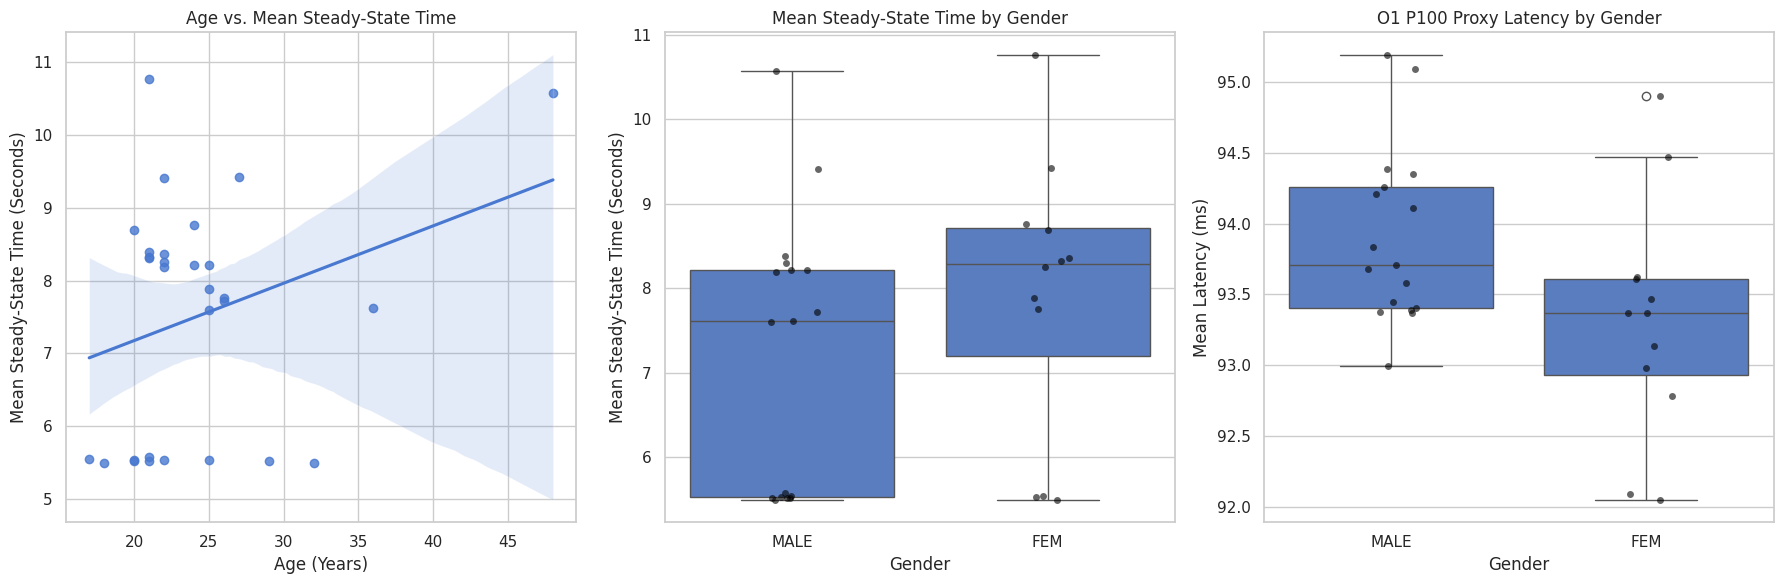

In [ ]:
print("\nStep 3: Generating demographic and target visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.regplot(
    x="Age",
    y="Mean_Steady_State_Time",
    data=subject_df,
    ax=axes[0],
    scatter_kws={"alpha": 0.8},
)

axes[0].set_title("Age vs. Mean Steady-State Time")
axes[0].set_xlabel("Age (Years)")
axes[0].set_ylabel("Mean Steady-State Time (Seconds)")

sns.boxplot(
    x="Gender",
    y="Mean_Steady_State_Time",
    data=subject_df,
    ax=axes[1],
)

sns.stripplot(
    x="Gender",
    y="Mean_Steady_State_Time",
    data=subject_df,
    ax=axes[1],
    color="black",
    alpha=0.6,
)

axes[1].set_title("Mean Steady-State Time by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Mean Steady-State Time (Seconds)")

sns.boxplot(
    x="Gender",
    y="Mean_O1_P100_Proxy_Latency_ms",
    data=subject_df,
    ax=axes[2],
)

sns.stripplot(
    x="Gender",
    y="Mean_O1_P100_Proxy_Latency_ms",
    data=subject_df,
    ax=axes[2],
    color="black",
    alpha=0.6,
)

axes[2].set_title("O1 P100 Proxy Latency by Gender")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Mean Latency (ms)")

plt.tight_layout()
plt.savefig("EDA_Demographics_Targets.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
print("\nStep 4: Statistical baseline: Gender difference in O1 P100 proxy latency...")

subject_df["Gender_Clean"] = (
    subject_df["Gender"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        "M": "MALE",
        "MAN": "MALE",
        "F": "FEMALE",
        "FEM": "FEMALE",
        "WOMAN": "FEMALE",
    })
)

print("Gender counts:")
print(subject_df["Gender_Clean"].value_counts())

male_latency = subject_df.loc[
    subject_df["Gender_Clean"] == "MALE",
    "Mean_O1_P100_Proxy_Latency_ms",
].dropna()

female_latency = subject_df.loc[
    subject_df["Gender_Clean"] == "FEMALE",
    "Mean_O1_P100_Proxy_Latency_ms",
].dropna()

print(f"\nMale subjects: {len(male_latency)}")
print(f"Female subjects: {len(female_latency)}")

if len(male_latency) < 3 or len(female_latency) < 3:
    print("Not enough subjects per group for a reliable statistical test.")
else:
    t_stat, t_p = stats.ttest_ind(
        male_latency,
        female_latency,
        equal_var=False,
    )

    u_stat, u_p = stats.mannwhitneyu(
        male_latency,
        female_latency,
        alternative="two-sided",
    )

    print("\n--- Welch's T-Test: O1 P100 Proxy Latency ---")
    print(f"Male mean latency:   {male_latency.mean():.2f} ms")
    print(f"Female mean latency: {female_latency.mean():.2f} ms")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value:     {t_p:.4f}")

    print("\n--- Mann-Whitney U Test: Robust Nonparametric Check ---")
    print(f"U-statistic: {u_stat:.4f}")
    print(f"P-value:     {u_p:.4f}")

    if t_p < 0.05:
        print("\nInterpretation: The subject-level Welch t-test suggests a statistically significant gender difference.")
    else:
        print("\nInterpretation: The subject-level Welch t-test does not show a statistically significant gender difference.")



Step 4: Statistical baseline: Gender difference in O1 P100 proxy latency...
Gender counts:
Gender_Clean
MALE      17
FEMALE    12
Name: count, dtype: int64

Male subjects: 17
Female subjects: 12

--- Welch's T-Test: O1 P100 Proxy Latency ---
Male mean latency:   93.91 ms
Female mean latency: 93.32 ms
T-statistic: 2.0676
P-value:     0.0524

--- Mann-Whitney U Test: Robust Nonparametric Check ---
U-statistic: 149.0000
P-value:     0.0395

Interpretation: The subject-level Welch t-test does not show a statistically significant gender difference.



Step 5: Channel correlation heatmap for Alpha power...


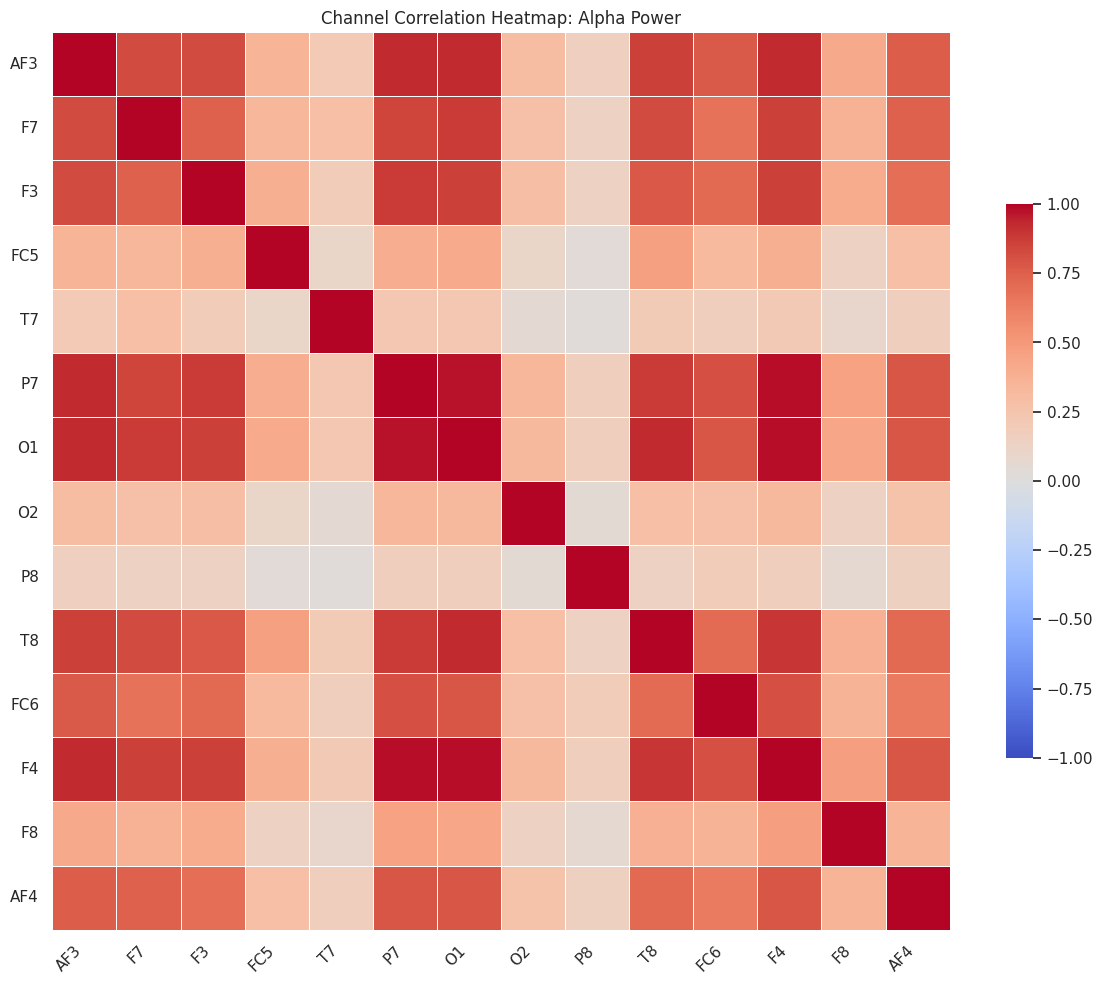


--- PHASE 3 COMPLETE ---
Saved: EDA_Demographics_Targets.png
Saved: EDA_Channel_Correlation.png


In [ ]:
print("\nStep 5: Channel correlation heatmap for Alpha power...")

alpha_cols = [col for col in df_ml.columns if col.endswith("_Alpha_Power")]

if not alpha_cols:
    raise ValueError("No Alpha power columns found. Check Phase 2 feature names.")

session_alpha_df = (
    df_ml
    .groupby("Session_ID", as_index=False)[alpha_cols]
    .mean()
)

corr_matrix = session_alpha_df[alpha_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.6},
)

labels = [col.replace("_Alpha_Power", "") for col in alpha_cols]

plt.title("Channel Correlation Heatmap: Alpha Power")
plt.xticks(
    ticks=[i + 0.5 for i in range(len(labels))],
    labels=labels,
    rotation=45,
    ha="right",
)
plt.yticks(
    ticks=[i + 0.5 for i in range(len(labels))],
    labels=labels,
    rotation=0,
)

plt.tight_layout()
plt.savefig("EDA_Channel_Correlation.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n--- PHASE 3 COMPLETE ---")
print("Saved: EDA_Demographics_Targets.png")
print("Saved: EDA_Channel_Correlation.png")


## Phase 3 Summary: EDA & Statistical Baselines

Phase 3 explored demographic trends, group-level statistical differences, and multicollinearity before predictive modeling.

The Age vs. Steady-State Time plot showed an upward trend, suggesting that older subjects may require longer time to reach a steady-state ssVEP response. However, the confidence interval was wide, especially at higher ages, so this should be interpreted as exploratory evidence rather than proof.

The Gender vs. Steady-State Time plot showed substantial overlap between male and female subjects, meaning any gender-related difference in focus speed should be interpreted cautiously.

For the O1 P100 latency proxy, male subjects showed a slightly higher mean latency than female subjects:

- Male mean latency: 93.91 ms
- Female mean latency: 93.32 ms
- Welch's t-test: p = 0.0524
- Mann-Whitney U test: p = 0.0395

The Welch t-test narrowly missed the conventional p < 0.05 threshold, while the nonparametric Mann-Whitney U test suggested a significant distributional difference. Because the sample size is small and the feature is a P100 proxy rather than event-locked clinical P100, this result should be described as suggestive rather than conclusive.

The Alpha-band channel correlation heatmap showed broad positive correlations across EEG channels. This indicates multicollinearity among EEG predictors and supports the use of regularized models such as Ridge Regression, as well as comparison with tree-based models like Random Forest and XGBoost.

Important methodological note: all statistical testing was performed at the subject level rather than the epoch level to avoid pseudoreplication from repeated EEG epochs belonging to the same participant.


## Phase 4: Predictive Modeling Pipeline

With EDA complete, we now begin the main predictive modeling phase.

Task 1 is BCI Intent Recognition. The goal is to determine whether a model can classify the experimental task, `Test_Name`, from one second of EEG frequency-power features.

Because the dataset contains many 1-second epochs from only 29 subjects, ordinary random splitting would cause severe data leakage. If epochs from the same subject appeared in both training and testing sets, the model could learn subject-specific EEG patterns rather than task-specific brain responses.

To prevent this, we use grouped cross-validation, where all epochs from the same subject stay together in either the training fold or the validation fold.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import cross_val_predict

try:
    from sklearn.model_selection import StratifiedGroupKFold
    CV_CLASS = StratifiedGroupKFold
    cv = CV_CLASS(n_splits=5, shuffle=True, random_state=42)
    print("Using StratifiedGroupKFold.")
except ImportError:
    from sklearn.model_selection import GroupKFold
    CV_CLASS = GroupKFold
    cv = CV_CLASS(n_splits=5)
    print("Using GroupKFold.")


print("Step 1: Loading ML-ready epoch dataset...")

df_ml = pd.read_csv("ML_Ready_EEG_Features.csv")

feature_cols = [
    col for col in df_ml.columns
    if col.endswith("_Alpha_Power")
    or col.endswith("_Beta_Power")
    or col.endswith("_Gamma_Power")
]

required_cols = ["Test_Name", "Subject_ID", *feature_cols]
missing_cols = [col for col in required_cols if col not in df_ml.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

X = df_ml[feature_cols].copy()
y = df_ml["Test_Name"].astype(str)
groups = df_ml["Subject_ID"].astype(str)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

labels = sorted(y.unique())

print(f"Total epochs: {len(X)}")
print(f"Total subjects: {groups.nunique()}")
print(f"Intent classes: {len(labels)}")
print(f"Frequency-power features: {len(feature_cols)}")

print("\nClass distribution:")
print(y.value_counts())


Using StratifiedGroupKFold.
Step 1: Loading ML-ready epoch dataset...
Total epochs: 9657
Total subjects: 29
Intent classes: 5
Frequency-power features: 42

Class distribution:
Test_Name
IMAGE SEARCH    2186
FIVE BOX 1      2062
FIVE BOX 2      1957
FIVE BOX 3      1939
HAND SHAKE      1513
Name: count, dtype: int64


In [ ]:
print("\nStep 2: Running majority-class baseline...")

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_pred = cross_val_predict(
    dummy_model,
    X,
    y,
    groups=groups,
    cv=cv,
)

dummy_accuracy = accuracy_score(y, dummy_pred)
dummy_macro_f1 = f1_score(y, dummy_pred, average="macro")

print(f"Baseline accuracy: {dummy_accuracy * 100:.2f}%")
print(f"Baseline macro F1: {dummy_macro_f1:.4f}")



Step 2: Running majority-class baseline...
Baseline accuracy: 22.64%
Baseline macro F1: 0.0738


In [ ]:
print("\nStep 3: Training Random Forest intent decoder...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_features="sqrt",
)

print("Running grouped cross-validation. This may take a few minutes...")

y_pred = cross_val_predict(
    rf_model,
    X,
    y,
    groups=groups,
    cv=cv,
)

accuracy = accuracy_score(y, y_pred)
macro_f1 = f1_score(y, y_pred, average="macro")

print("\nStep 4: Evaluating model performance...")
print(f"Grouped CV accuracy: {accuracy * 100:.2f}%")
print(f"Grouped CV macro F1: {macro_f1:.4f}")

print("\nDetailed classification report:")
print(classification_report(y, y_pred, labels=labels))



Step 3: Training Random Forest intent decoder...
Running grouped cross-validation. This may take a few minutes...

Step 4: Evaluating model performance...
Grouped CV accuracy: 27.86%
Grouped CV macro F1: 0.2609

Detailed classification report:
              precision    recall  f1-score   support

  FIVE BOX 1       0.23      0.20      0.22      2062
  FIVE BOX 2       0.27      0.22      0.24      1957
  FIVE BOX 3       0.29      0.34      0.31      1939
  HAND SHAKE       0.20      0.13      0.16      1513
IMAGE SEARCH       0.32      0.46      0.38      2186

    accuracy                           0.28      9657
   macro avg       0.26      0.27      0.26      9657
weighted avg       0.27      0.28      0.27      9657




Step 5: Generating confusion matrices...


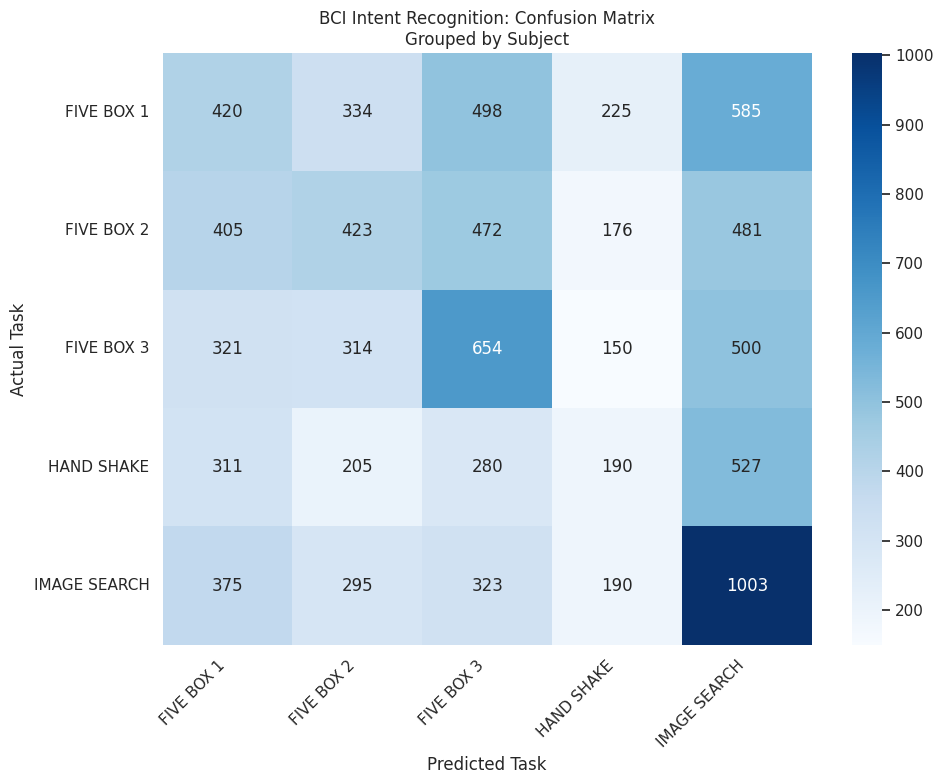

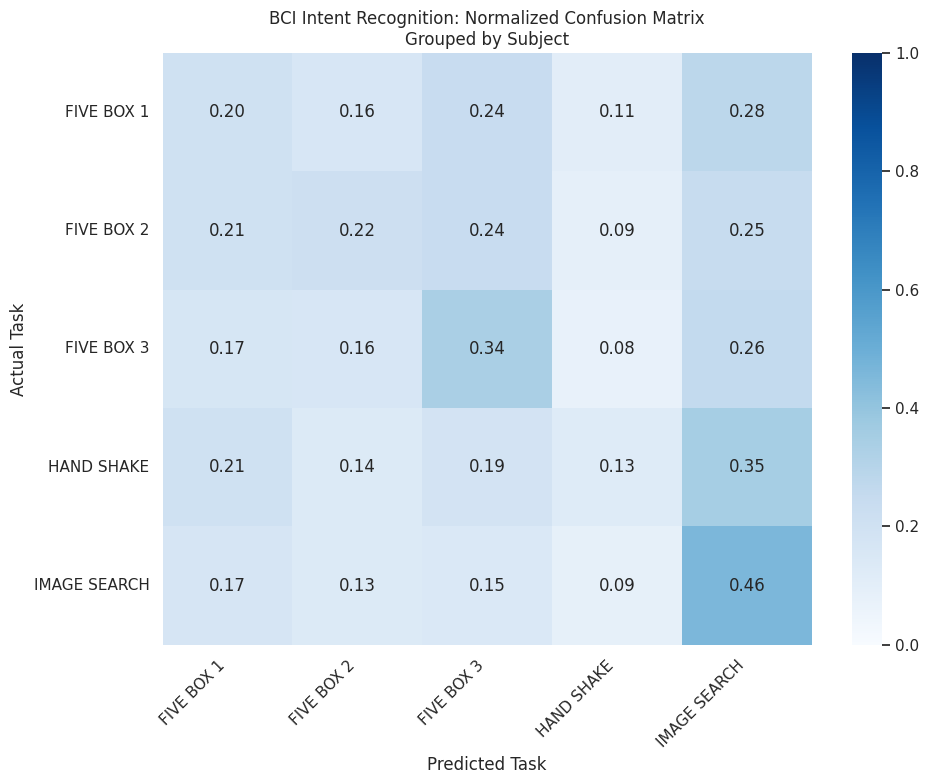


--- TASK 1 CLASSIFICATION COMPLETE ---
Saved: Classification_Confusion_Matrix_Counts.png
Saved: Classification_Confusion_Matrix_Normalized.png


In [ ]:
print("\nStep 5: Generating confusion matrices...")

cm = confusion_matrix(y, y_pred, labels=labels)
cm_normalized = confusion_matrix(y, y_pred, labels=labels, normalize="true")

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)

plt.title("BCI Intent Recognition: Confusion Matrix\nGrouped by Subject")
plt.ylabel("Actual Task")
plt.xlabel("Predicted Task")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Classification_Confusion_Matrix_Counts.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    vmin=0,
    vmax=1,
)

plt.title("BCI Intent Recognition: Normalized Confusion Matrix\nGrouped by Subject")
plt.ylabel("Actual Task")
plt.xlabel("Predicted Task")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Classification_Confusion_Matrix_Normalized.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n--- TASK 1 CLASSIFICATION COMPLETE ---")
print("Saved: Classification_Confusion_Matrix_Counts.png")
print("Saved: Classification_Confusion_Matrix_Normalized.png")


## Task 1 Result: Random Forest Intent Classification

The Random Forest classifier achieved 27.86% grouped cross-validated accuracy and a macro F1-score of 0.2609 across five task classes.

Because validation was grouped by `Subject_ID`, this result evaluates whether the model generalizes to unseen subjects rather than memorizing subject-specific EEG patterns. The model performs above the approximate 20% chance level expected for five balanced classes, suggesting that the frequency-power features contain some task-relevant information.

However, performance remains modest. The strongest class was `IMAGE SEARCH`, with an F1-score of 0.38 and recall of 0.46, indicating that this task may produce a more distinguishable EEG signature. The weakest class was `HAND SHAKE`, with an F1-score of 0.16, suggesting that it is either harder to distinguish from the other tasks or underrepresented in the available feature space.

The three `FIVE BOX` conditions show overlapping performance, which is expected because these tasks are visually similar and may evoke similar ssVEP/frequency responses.

Overall, the Random Forest result provides early evidence of subject-generalizable intent decoding, but the model comparison phase should continue with Logistic Regression, SVM, KNN, and XGBoost before drawing final conclusions.


## Confusion Matrix Interpretation

The normalized confusion matrix shows that the Random Forest model is not simply guessing uniformly. It shows a clear bias toward predicting `IMAGE SEARCH`, but it also captures some class-specific structure.

`IMAGE SEARCH` is the most recognizable class, with 46% recall. This means nearly half of true `IMAGE SEARCH` epochs were correctly identified. This supports the idea that `IMAGE SEARCH` may produce a more distinct EEG frequency-power pattern than the other tasks.

`FIVE BOX 3` is the second strongest class, with 34% recall. The other two Five Box conditions are weaker, with `FIVE BOX 1` at 20% recall and `FIVE BOX 2` at 22% recall. This suggests that the three Five Box tasks share overlapping EEG signatures, which is expected because they are visually and cognitively similar.

`HAND SHAKE` is the weakest class, with only 13% recall. Most `HAND SHAKE` epochs are misclassified as `IMAGE SEARCH`, `FIVE BOX 1`, or `FIVE BOX 3`. This suggests that the current frequency-band features may not capture the specific neural dynamics needed to distinguish this task.

A key pattern is that the model overpredicts `IMAGE SEARCH`. This may reflect a stronger or more consistent signal for that class, but it may also indicate class imbalance or feature overlap. Future improvements should compare additional classifiers, tune hyperparameters, and consider adding temporal or channel-specific features beyond average Alpha, Beta, and Gamma power.


In [ ]:
prediction_distribution = pd.Series(y_pred).value_counts(normalize=True).sort_index()

print("Prediction distribution:")
print((prediction_distribution * 100).round(2))


Prediction distribution:
FIVE BOX 1      18.97
FIVE BOX 2      16.27
FIVE BOX 3      23.06
HAND SHAKE       9.64
IMAGE SEARCH    32.06
Name: proportion, dtype: float64


## Prediction Distribution Check

The prediction distribution shows that the Random Forest model overpredicts `IMAGE SEARCH` and underpredicts `HAND SHAKE`.

Predicted class distribution:

- `FIVE BOX 1`: 18.97%
- `FIVE BOX 2`: 16.27%
- `FIVE BOX 3`: 23.06%
- `HAND SHAKE`: 9.64%
- `IMAGE SEARCH`: 32.06%

This explains part of the confusion matrix pattern. `IMAGE SEARCH` is predicted almost one-third of the time, which is higher than its true dataset proportion of approximately 22.64%. Meanwhile, `HAND SHAKE` is predicted less than 10% of the time, even though it represents approximately 15.67% of the true labels.

This suggests that the current Random Forest model has learned a decision boundary that favors `IMAGE SEARCH` and struggles to confidently identify `HAND SHAKE`. The behavior may be caused by overlapping EEG frequency signatures, limited discriminative power of Alpha/Beta/Gamma features, or class imbalance.

For the next modeling step, we should compare additional classifiers and include macro F1-score as a primary metric, since macro F1 penalizes poor performance on underpredicted classes like `HAND SHAKE`.

The prediction distribution revealed a model-level bias toward `IMAGE SEARCH`, which accounted for 32.06% of predictions despite representing about 22.64% of the true labels. Conversely, `HAND SHAKE` was underpredicted at 9.64%. This imbalance helps explain the weak recall for `HAND SHAKE` and supports the use of macro F1-score alongside accuracy in subsequent model comparisons.


In [ ]:
import time
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import cross_val_predict

try:
    from sklearn.model_selection import StratifiedGroupKFold
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    print("Using StratifiedGroupKFold.")
except ImportError:
    from sklearn.model_selection import GroupKFold
    cv = GroupKFold(n_splits=5)
    print("Using GroupKFold.")

try:
    from xgboost import XGBClassifier
    xgboost_available = True
    print("XGBoost is available.")
except ImportError:
    xgboost_available = False
    print("XGBoost is not installed. Skipping XGBoost for now.")


Using StratifiedGroupKFold.
XGBoost is available.


In [ ]:
print("Preparing classification features...")

df_ml = pd.read_csv("ML_Ready_EEG_Features.csv")

feature_cols = [
    col for col in df_ml.columns
    if col.endswith("_Alpha_Power")
    or col.endswith("_Beta_Power")
    or col.endswith("_Gamma_Power")
]

X = df_ml[feature_cols].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

y_raw = df_ml["Test_Name"].astype(str)
groups = df_ml["Subject_ID"].astype(str)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

models = {
    "Dummy Majority Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        )),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7,
            weights="distance",
        )),
    ]),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        max_features="sqrt",
    ),
}

if xgboost_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

results = []
predictions = {}

for model_name, model in models.items():
    print(f"\nTraining and evaluating: {model_name}")
    start_time = time.time()

    if model_name == "XGBoost":
        y_for_model = y_encoded
        y_pred_encoded = cross_val_predict(
            model,
            X,
            y_for_model,
            groups=groups,
            cv=cv,
        )
        y_pred = label_encoder.inverse_transform(y_pred_encoded)
        y_true = y_raw
    else:
        y_pred = cross_val_predict(
            model,
            X,
            y_raw,
            groups=groups,
            cv=cv,
        )
        y_true = y_raw

    elapsed = time.time() - start_time

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1,
        "Runtime_Seconds": elapsed,
    })

    predictions[model_name] = y_pred

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Runtime: {elapsed:.1f} seconds")

results_df = (
    pd.DataFrame(results)
    .sort_values("Macro_F1", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

results_df.to_csv("Classification_Model_Comparison.csv", index=False)
print("Saved: Classification_Model_Comparison.csv")


Preparing classification features...

Training and evaluating: Dummy Majority Baseline
Accuracy: 0.2264
Macro F1: 0.0738
Runtime: 0.3 seconds

Training and evaluating: Logistic Regression
Accuracy: 0.2562
Macro F1: 0.2400
Runtime: 16.9 seconds

Training and evaluating: KNN
Accuracy: 0.2267
Macro F1: 0.2221
Runtime: 0.8 seconds

Training and evaluating: SVM RBF
Accuracy: 0.2257
Macro F1: 0.1664
Runtime: 46.0 seconds

Training and evaluating: Random Forest
Accuracy: 0.2786
Macro F1: 0.2609
Runtime: 133.4 seconds

Training and evaluating: XGBoost
Accuracy: 0.2557
Macro F1: 0.2448
Runtime: 54.9 seconds


,Model,Accuracy,Macro_F1,Weighted_F1,Runtime_Seconds
0,Random Forest,0.278554,0.260949,0.268025,133.403219
1,XGBoost,0.255669,0.244842,0.249667,54.927408
2,Logistic Regression,0.256187,0.240045,0.243239,16.894660
3,KNN,0.226675,0.222100,0.226328,0.779746
4,SVM RBF,0.225743,0.166431,0.169657,46.014275
5,Dummy Majority Baseline,0.226364,0.073833,0.083565,0.322410


Saved: Classification_Model_Comparison.csv


## Task 1B: Intent Classification Model Comparison

Five classifiers were evaluated using subject-grouped cross-validation, with a majority-class dummy classifier included as a baseline. Macro F1-score was used as the primary ranking metric because the classes are not perfectly balanced and some classes, especially `HAND SHAKE`, are harder to detect.

The best-performing model was Random Forest:

- Accuracy: 27.86%
- Macro F1: 0.2609
- Weighted F1: 0.2680

Random Forest outperformed the Dummy baseline, which achieved 22.64% accuracy but only 0.0738 macro F1. This shows that the model is learning more than just the majority class.

XGBoost and Logistic Regression performed similarly, with macro F1-scores of 0.2448 and 0.2400. This suggests that both nonlinear boosted trees and linear decision boundaries capture some task-relevant EEG structure, although neither exceeded Random Forest in this configuration.

KNN had near-baseline accuracy but a higher macro F1 than the Dummy model, indicating limited minority-class sensitivity but weak overall discrimination.

SVM with an RBF kernel performed poorly in this feature space, with macro F1 of 0.1664, suggesting that the chosen SVM configuration did not separate the task classes effectively.

Overall, the classification results provide modest evidence of subject-generalizable EEG intent decoding. The best model exceeded the majority-class baseline by approximately 5.22 percentage points in accuracy and substantially improved macro F1. However, performance remains limited, so the result should be described as weak-to-moderate decoding rather than a high-accuracy BCI system.


**Among the tested classifiers, Random Forest achieved the strongest subject-generalized intent decoding performance, with 27.86% accuracy and 0.2609 macro F1 under grouped cross-validation. This exceeded the majority-class baseline of 22.64% accuracy and 0.0738 macro F1, indicating that EEG frequency-band features contain task-relevant information, though classification performance remains modest.**


**The current Alpha/Beta/Gamma power features provide modest subject-generalizable task information, but they are not sufficient for high-confidence intent classification.**




# A. Binary Classification: IMAGE SEARCH vs OTHER



In [ ]:
import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_predict

try:
    from sklearn.model_selection import StratifiedGroupKFold
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
except ImportError:
    from sklearn.model_selection import GroupKFold
    cv = GroupKFold(n_splits=5)

df_ml = pd.read_csv("ML_Ready_EEG_Features.csv")

feature_cols = [
    col for col in df_ml.columns
    if col.endswith("_Alpha_Power")
    or col.endswith("_Beta_Power")
    or col.endswith("_Gamma_Power")
]

X = df_ml[feature_cols].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

y_binary = np.where(df_ml["Test_Name"].astype(str) == "IMAGE SEARCH", "IMAGE SEARCH", "OTHER")
groups = df_ml["Subject_ID"].astype(str)

binary_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_features="sqrt",
)

start = time.time()

y_pred_binary = cross_val_predict(
    binary_rf,
    X,
    y_binary,
    groups=groups,
    cv=cv,
)

elapsed = time.time() - start

print("Binary Classification: IMAGE SEARCH vs OTHER")
print(f"Runtime: {elapsed:.1f} seconds")
print(f"Accuracy: {accuracy_score(y_binary, y_pred_binary):.4f}")
print(f"Macro F1: {f1_score(y_binary, y_pred_binary, average='macro'):.4f}")
print("\nClassification report:")
print(classification_report(y_binary, y_pred_binary))

cm = confusion_matrix(y_binary, y_pred_binary, labels=["IMAGE SEARCH", "OTHER"])
print("\nConfusion matrix:")
print(pd.DataFrame(cm, index=["Actual IMAGE SEARCH", "Actual OTHER"], columns=["Pred IMAGE SEARCH", "Pred OTHER"]))


Binary Classification: IMAGE SEARCH vs OTHER
Runtime: 160.8 seconds
Accuracy: 0.7652
Macro F1: 0.4522

Classification report:
              precision    recall  f1-score   support

IMAGE SEARCH       0.26      0.02      0.04      2186
       OTHER       0.77      0.98      0.87      7471

    accuracy                           0.77      9657
   macro avg       0.52      0.50      0.45      9657
weighted avg       0.66      0.77      0.68      9657


Confusion matrix:
                     Pred IMAGE SEARCH  Pred OTHER
Actual IMAGE SEARCH                 45        2141
Actual OTHER                       126        7345


# B. Session-Level Classification
This averages features over each full session, then classifies sessions instead of noisy 1-second epochs.



In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

session_df = (
    df_ml
    .groupby("Session_ID", as_index=False)
    .agg(
        Subject_ID=("Subject_ID", "first"),
        Test_Name=("Test_Name", "first"),
        **{col: (col, "mean") for col in feature_cols}
    )
)

X_session = session_df[feature_cols].replace([np.inf, -np.inf], np.nan)
X_session = X_session.fillna(X_session.median(numeric_only=True))

y_session = session_df["Test_Name"].astype(str)
groups_session = session_df["Subject_ID"].astype(str)

print(f"Session-level rows: {len(session_df)}")
print(f"Subjects: {groups_session.nunique()}")
print("\nSession class distribution:")
print(y_session.value_counts())

session_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_features="sqrt",
)

y_pred_session = cross_val_predict(
    session_rf,
    X_session,
    y_session,
    groups=groups_session,
    cv=cv,
)

print("\nSession-Level 5-Class Classification")
print(f"Accuracy: {accuracy_score(y_session, y_pred_session):.4f}")
print(f"Macro F1: {f1_score(y_session, y_pred_session, average='macro'):.4f}")
print("\nClassification report:")
print(classification_report(y_session, y_pred_session))


Session-level rows: 138
Subjects: 29

Session class distribution:
Test_Name
FIVE BOX 1      29
HAND SHAKE      29
FIVE BOX 2      27
FIVE BOX 3      27
IMAGE SEARCH    26
Name: count, dtype: int64

Session-Level 5-Class Classification
Accuracy: 0.2391
Macro F1: 0.2378

Classification report:
              precision    recall  f1-score   support

  FIVE BOX 1       0.16      0.14      0.15        29
  FIVE BOX 2       0.32      0.33      0.33        27
  FIVE BOX 3       0.30      0.22      0.26        27
  HAND SHAKE       0.21      0.31      0.25        29
IMAGE SEARCH       0.23      0.19      0.21        26

    accuracy                           0.24       138
   macro avg       0.24      0.24      0.24       138
weighted avg       0.24      0.24      0.24       138



The binary `IMAGE SEARCH` vs `OTHER` classifier achieved 76.52% accuracy, but this result is misleading because the model overwhelmingly predicted the majority class, `OTHER`. Only 45 of 2,186 true `IMAGE SEARCH` epochs were correctly detected, giving `IMAGE SEARCH` recall of 0.02 and F1-score of 0.04.

Therefore, the binary epoch-level classifier should not be interpreted as a successful `IMAGE SEARCH` detector. Macro F1-score and class-specific recall reveal that the model failed to identify the minority class reliably.


In [ ]:
y_session_binary = np.where(y_session == "IMAGE SEARCH", "IMAGE SEARCH", "OTHER")

y_pred_session_binary = cross_val_predict(
    session_rf,
    X_session,
    y_session_binary,
    groups=groups_session,
    cv=cv,
)

print("\nSession-Level Binary Classification: IMAGE SEARCH vs OTHER")
print(f"Accuracy: {accuracy_score(y_session_binary, y_pred_session_binary):.4f}")
print(f"Macro F1: {f1_score(y_session_binary, y_pred_session_binary, average='macro'):.4f}")
print("\nClassification report:")
print(classification_report(y_session_binary, y_pred_session_binary))



Session-Level Binary Classification: IMAGE SEARCH vs OTHER
Accuracy: 0.8116
Macro F1: 0.4480

Classification report:
              precision    recall  f1-score   support

IMAGE SEARCH       0.00      0.00      0.00        26
       OTHER       0.81      1.00      0.90       112

    accuracy                           0.81       138
   macro avg       0.41      0.50      0.45       138
weighted avg       0.66      0.81      0.73       138



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Session-level classification produced 23.91% accuracy and 0.2378 macro F1 across five nearly balanced classes. This is only slightly above the 20% chance level for five classes and did not improve over epoch-level Random Forest classification.

This suggests that simply averaging broad Alpha/Beta/Gamma power features over full sessions does not create a stronger task signature. The task information may be too weak in these broad-band features, or the relevant ssVEP information may require more targeted stimulus-frequency features.


Broad-band EEG power features are weak for subject-generalized task classification.


# C. Regression: Steady-State Time and P100 Proxy

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_predict

regression_feature_cols = feature_cols + ["Age", "Gender", "Test_Name"]
regression_cv = GroupKFold(n_splits=5)
reg_df = df_ml.copy()
reg_df["Gender"] = reg_df["Gender"].astype(str).str.strip().str.upper().replace({"FEM": "FEMALE", "M": "MALE", "F": "FEMALE"})

numeric_features = feature_cols + ["Age"]
categorical_features = ["Gender", "Test_Name"]

preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)


regression_models = {
    "Dummy Mean": Pipeline([
        ("preprocess", preprocess_tree),
        ("model", DummyRegressor(strategy="mean")),
    ]),
    "Linear Regression": Pipeline([
        ("preprocess", preprocess_linear),
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline([
        ("preprocess", preprocess_linear),
        ("model", Ridge(alpha=10.0)),
    ]),
    "Random Forest Regressor": Pipeline([
        ("preprocess", preprocess_tree),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            max_features="sqrt",
        )),
    ]),
}

def evaluate_regression_target(target_col):
    print(f"\nRegression target: {target_col}")

    data = reg_df.dropna(subset=[target_col]).copy()
    data = data.dropna(subset=["Subject_ID"])

    X_reg = data[regression_feature_cols]
    y_reg = data[target_col]
    groups_reg = data["Subject_ID"].astype(str)

    rows = []

    for model_name, model in regression_models.items():
        print(f"Evaluating: {model_name}")
        start = time.time()

        y_pred = cross_val_predict(
            model,
            X_reg,
            y_reg,
            groups=groups_reg,
            cv=regression_cv,
        )

        elapsed = time.time() - start

        rmse = mean_squared_error(y_reg, y_pred) ** 0.5
        mae = mean_absolute_error(y_reg, y_pred)
        r2 = r2_score(y_reg, y_pred)

        rows.append({
            "Target": target_col,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Runtime_Seconds": elapsed,
        })

        print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

    return pd.DataFrame(rows)

steady_results = evaluate_regression_target("Steady_State_Time")
p100_results = evaluate_regression_target("O1_P100_Proxy_Latency_ms")

regression_results_df = pd.concat([steady_results, p100_results], ignore_index=True)
display(regression_results_df.sort_values(["Target", "MAE"]))

regression_results_df.to_csv("Regression_Model_Comparison.csv", index=False)
print("Saved: Regression_Model_Comparison.csv")



Regression target: Steady_State_Time
Evaluating: Dummy Mean
RMSE: 6.2497 | MAE: 4.0073 | R2: -0.0062
Evaluating: Linear Regression
RMSE: 5.6779 | MAE: 1.6317 | R2: 0.1695
Evaluating: Ridge Regression
RMSE: 4.5532 | MAE: 1.5858 | R2: 0.4659
Evaluating: Random Forest Regressor
RMSE: 3.4517 | MAE: 1.4265 | R2: 0.6931

Regression target: O1_P100_Proxy_Latency_ms
Evaluating: Dummy Mean
RMSE: 12.7090 | MAE: 11.3940 | R2: -0.0002
Evaluating: Linear Regression
RMSE: 16.2023 | MAE: 11.6505 | R2: -0.6256
Evaluating: Ridge Regression
RMSE: 13.3168 | MAE: 11.5515 | R2: -0.0981
Evaluating: Random Forest Regressor
RMSE: 12.7905 | MAE: 11.5369 | R2: -0.0131


,Target,Model,RMSE,MAE,R2,Runtime_Seconds
4,O1_P100_Proxy_Latency_ms,Dummy Mean,12.709001,11.393980,-0.000182,0.376510
7,O1_P100_Proxy_Latency_ms,Random Forest Regressor,12.790516,11.536914,-0.013054,157.224670
6,O1_P100_Proxy_Latency_ms,Ridge Regression,13.316836,11.551508,-0.098142,0.888900
5,O1_P100_Proxy_Latency_ms,Linear Regression,16.202265,11.650520,-0.625578,0.677884
3,Steady_State_Time,Random Forest Regressor,3.451715,1.426461,0.693078,46.165761
2,Steady_State_Time,Ridge Regression,4.553154,1.585811,0.465948,0.616636
1,Steady_State_Time,Linear Regression,5.677929,1.631713,0.169502,0.641315
0,Steady_State_Time,Dummy Mean,6.249716,4.007273,-0.006188,0.381231


Saved: Regression_Model_Comparison.csv


## Regression Results

The strongest predictive task was `Steady_State_Time` regression. The Random Forest Regressor achieved the best performance:

- RMSE: 3.45 seconds
- MAE: 1.43 seconds
- R2: 0.6931

This substantially outperformed the Dummy Mean baseline, which had:

- RMSE: 6.25 seconds
- MAE: 4.01 seconds
- R2: -0.0062

This means the model explains approximately 69% of the variance in steady-state response time under subject-grouped cross-validation. Unlike the intent-classification task, this is a strong and reportable ML result.

Ridge Regression also performed reasonably well, with R2 = 0.4659, supporting the earlier EDA finding that multicollinearity exists but can be handled with regularization.

In contrast, `O1_P100_Proxy_Latency_ms` was not predictable from the current feature set. All models performed similarly to or worse than the Dummy Mean baseline, with negative R2 values. This suggests that the P100 proxy feature, as currently extracted from non-event-locked 1-second epochs, does not contain a stable learnable relationship with the available predictors.


# Feature Importance For Best Random Forest Models

,Feature,Importance
38,F8_Gamma_Power,0.037529
13,T7_Beta_Power,0.037107
29,T8_Gamma_Power,0.035784
0,AF3_Alpha_Power,0.034754
21,O2_Alpha_Power,0.034014
32,FC6_Gamma_Power,0.032899
14,T7_Gamma_Power,0.030939
1,AF3_Beta_Power,0.029813
15,P7_Alpha_Power,0.028720
2,AF3_Gamma_Power,0.027478


/tmp/ipykernel_8756/719578191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


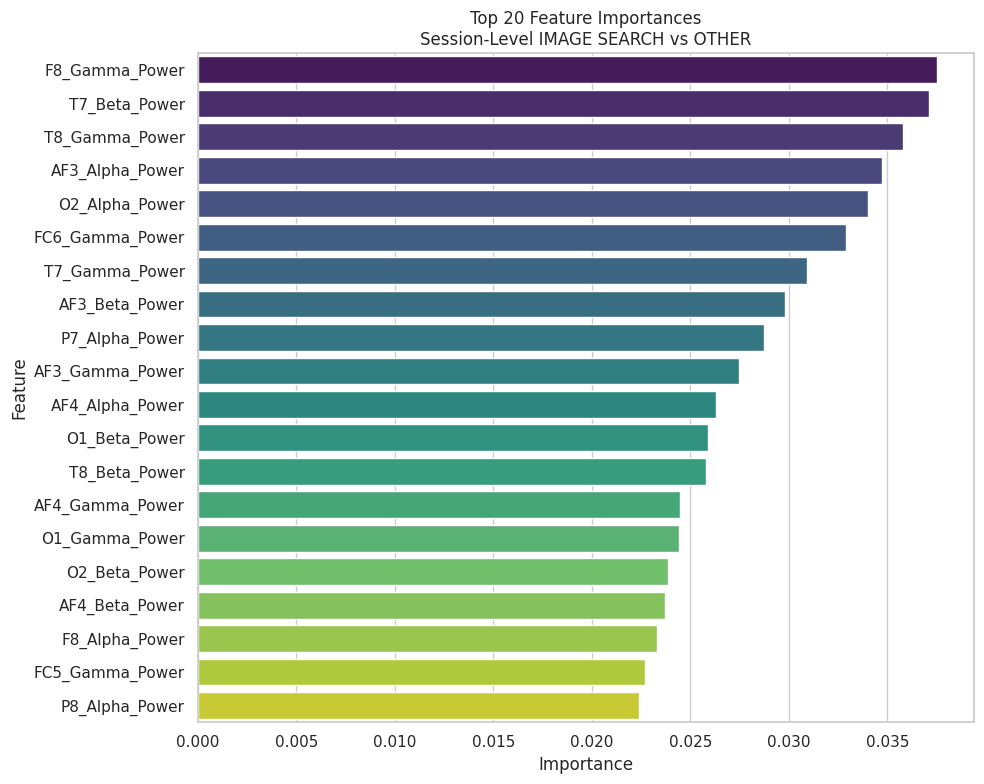

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

best_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_features="sqrt",
)

best_rf.fit(X_session, y_session_binary)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": best_rf.feature_importances_,
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x="Importance",
    y="Feature",
    palette="viridis",
)
plt.title("Top 20 Feature Importances\nSession-Level IMAGE SEARCH vs OTHER")
plt.tight_layout()
plt.savefig("Feature_Importance_Session_Binary_RF.png", dpi=300, bbox_inches="tight")
plt.show()


## Feature Importance Interpretation

The Random Forest feature importance results show that predictive information is distributed across multiple EEG channels and frequency bands rather than concentrated in one electrode.

Top-ranked features included:

- `F8_Gamma_Power`
- `T7_Beta_Power`
- `T8_Gamma_Power`
- `AF3_Alpha_Power`
- `O2_Alpha_Power`
- `FC6_Gamma_Power`
- `O1_Beta_Power`
- `O1_Gamma_Power`
- `O2_Beta_Power`

The presence of O1 and O2 features among the important predictors is encouraging because these occipital electrodes are associated with visual processing. However, the importance ranking is not exclusively occipital; frontal and temporal channels also contribute. This suggests that steady-state response time may reflect a broader cognitive and visuomotor process rather than only visual cortex activity.

Because Random Forest impurity-based feature importance can be biased toward correlated features, these results should be interpreted as exploratory. SHAP or permutation importance would provide a more robust interpretability analysis.


**The project did not produce a strong five-class second-by-second intent decoder, but it did produce a strong subject-generalized regression model for steady-state response time. This shifts the project’s main contribution from pure BCI intent classification to EEG-based prediction of cognitive/visual response efficiency.**

EEG frequency-band features can predict steady-state response time across unseen subjects with R2 ≈ 0.69, but broad-band features are insufficient for robust 5-class intent decoding.


Preparing final Steady-State Time regression model for interpretability

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


print("Preparing final Steady-State Time regression model for interpretability...")

df_ml = pd.read_csv("ML_Ready_EEG_Features.csv")

feature_cols = [
    col for col in df_ml.columns
    if col.endswith("_Alpha_Power")
    or col.endswith("_Beta_Power")
    or col.endswith("_Gamma_Power")
]

reg_df = df_ml.copy()
reg_df["Gender"] = (
    reg_df["Gender"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"FEM": "FEMALE", "M": "MALE", "F": "FEMALE"})
)

regression_feature_cols = feature_cols + ["Age", "Gender", "Test_Name"]
numeric_features = feature_cols + ["Age"]
categorical_features = ["Gender", "Test_Name"]

data = reg_df.dropna(subset=["Steady_State_Time", "Subject_ID"]).copy()

X_reg = data[regression_feature_cols]
y_reg = data["Steady_State_Time"]
groups_reg = data["Subject_ID"].astype(str)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

steady_rf_pipeline = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt",
    )),
])


Preparing final Steady-State Time regression model for interpretability...


grouped holdout split for interpretability

In [ ]:
print("Creating grouped holdout split for interpretability...")

gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(X_reg, y_reg, groups_reg))

X_train = X_reg.iloc[train_idx]
X_test = X_reg.iloc[test_idx]
y_train = y_reg.iloc[train_idx]
y_test = y_reg.iloc[test_idx]

train_subjects = set(groups_reg.iloc[train_idx])
test_subjects = set(groups_reg.iloc[test_idx])

print(f"Train rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print(f"Train subjects: {len(train_subjects)}")
print(f"Test subjects: {len(test_subjects)}")
print(f"Subject overlap: {len(train_subjects.intersection(test_subjects))}")


Creating grouped holdout split for interpretability...
Train rows: 7651
Test rows: 2006
Train subjects: 23
Test subjects: 6
Subject overlap: 0


In [ ]:
print("Fitting Random Forest regression pipeline...")

steady_rf_pipeline.fit(X_train, y_train)

y_test_pred = steady_rf_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f"Grouped holdout MAE: {mae:.4f} seconds")
print(f"Grouped holdout R2: {r2:.4f}")


Fitting Random Forest regression pipeline...
Grouped holdout MAE: 1.5322 seconds
Grouped holdout R2: 0.2772


permutation importance:

In [ ]:
print("Running permutation importance. This may take a few minutes...")

perm_result = permutation_importance(
    steady_rf_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_absolute_error",
)

perm_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std,
}).sort_values("Importance_Mean", ascending=False)

display(perm_importance_df.head(25))

perm_importance_df.to_csv("Permutation_Importance_Steady_State_RF.csv", index=False)
print("Saved: Permutation_Importance_Steady_State_RF.csv")


Running permutation importance. This may take a few minutes...


,Feature,Importance_Mean,Importance_Std
44,Test_Name,1.854038,0.064183
20,O1_Gamma_Power,0.013014,0.002301
8,F3_Gamma_Power,0.010994,0.001782
2,AF3_Gamma_Power,0.009797,0.002261
26,P8_Gamma_Power,0.008391,0.002781
5,F7_Gamma_Power,0.006610,0.002132
19,O1_Beta_Power,0.006379,0.003713
33,F4_Alpha_Power,0.004862,0.000729
4,F7_Beta_Power,0.003218,0.000848
38,F8_Gamma_Power,0.003129,0.000650


Saved: Permutation_Importance_Steady_State_RF.csv


Plot top features:

/tmp/ipykernel_8756/456626545.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


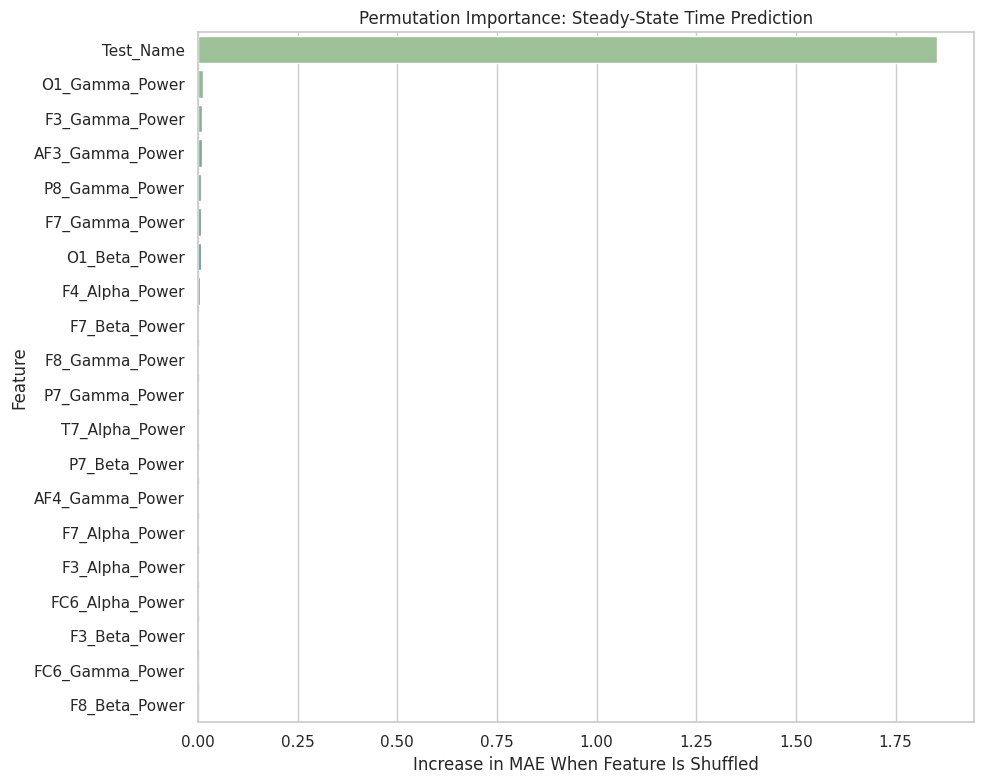

In [ ]:
top_n = 20

plt.figure(figsize=(10, 8))

sns.barplot(
    data=perm_importance_df.head(top_n),
    x="Importance_Mean",
    y="Feature",
    palette="crest",
)

plt.title("Permutation Importance: Steady-State Time Prediction")
plt.xlabel("Increase in MAE When Feature Is Shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("Permutation_Importance_Steady_State_RF.png", dpi=300, bbox_inches="tight")
plt.show()


actual vs predicted plot:

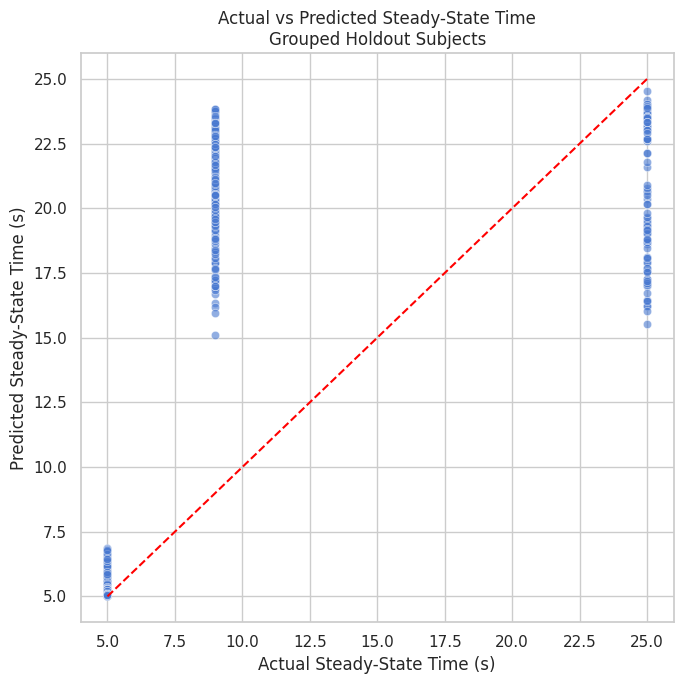

In [ ]:
plt.figure(figsize=(7, 7))

sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")

plt.title("Actual vs Predicted Steady-State Time\nGrouped Holdout Subjects")
plt.xlabel("Actual Steady-State Time (s)")
plt.ylabel("Predicted Steady-State Time (s)")
plt.tight_layout()
plt.savefig("Actual_vs_Predicted_Steady_State_Time.png", dpi=300, bbox_inches="tight")
plt.show()


Permutation importance showed that `Test_Name` was by far the dominant predictor of `Steady_State_Time`. This indicates that much of the regression performance comes from task identity rather than EEG features alone. This is scientifically plausible because different tasks may have different expected response durations, but it weakens any claim that EEG alone predicts steady-state response time.

To separate task-design effects from neural signal effects, a second regression model was evaluated without `Test_Name`. This tests whether EEG frequency features and demographics can predict steady-state time independently of knowing the task label.


Running EEG + demographics regression without Test_Name..

In [ ]:
print("Running EEG + demographics regression without Test_Name...")

regression_feature_cols_no_task = feature_cols + ["Age", "Gender"]
numeric_features_no_task = feature_cols + ["Age"]
categorical_features_no_task = ["Gender"]

X_reg_no_task = data[regression_feature_cols_no_task]

preprocess_tree_no_task = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features_no_task),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features_no_task),
    ]
)

steady_rf_no_task_pipeline = Pipeline([
    ("preprocess", preprocess_tree_no_task),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt",
    )),
])

X_train_no_task = X_reg_no_task.iloc[train_idx]
X_test_no_task = X_reg_no_task.iloc[test_idx]

steady_rf_no_task_pipeline.fit(X_train_no_task, y_train)

y_test_pred_no_task = steady_rf_no_task_pipeline.predict(X_test_no_task)

mae_no_task = mean_absolute_error(y_test, y_test_pred_no_task)
r2_no_task = r2_score(y_test, y_test_pred_no_task)

print(f"No-task grouped holdout MAE: {mae_no_task:.4f} seconds")
print(f"No-task grouped holdout R2: {r2_no_task:.4f}")


Running EEG + demographics regression without Test_Name...
No-task grouped holdout MAE: 3.5310 seconds
No-task grouped holdout R2: -0.2307


In [ ]:
print("Running permutation importance without Test_Name...")

perm_result_no_task = permutation_importance(
    steady_rf_no_task_pipeline,
    X_test_no_task,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_absolute_error",
)

perm_importance_no_task_df = pd.DataFrame({
    "Feature": X_test_no_task.columns,
    "Importance_Mean": perm_result_no_task.importances_mean,
    "Importance_Std": perm_result_no_task.importances_std,
}).sort_values("Importance_Mean", ascending=False)

display(perm_importance_no_task_df.head(25))


Running permutation importance without Test_Name...


,Feature,Importance_Mean,Importance_Std
43,Gender,0.262831,0.011598
13,T7_Beta_Power,0.133164,0.015661
14,T7_Gamma_Power,0.126446,0.005756
26,P8_Gamma_Power,0.124371,0.009158
24,P8_Alpha_Power,0.077807,0.005577
39,AF4_Alpha_Power,0.070861,0.002068
40,AF4_Beta_Power,0.068986,0.004384
30,FC6_Alpha_Power,0.068417,0.002537
27,T8_Alpha_Power,0.063364,0.001940
9,FC5_Alpha_Power,0.061616,0.002704


## No-Task Regression Interpretability

After removing `Test_Name`, permutation importance showed that `Gender` became the strongest predictor of `Steady_State_Time`. This indicates that the model was not relying only on task identity; demographic and EEG features still contributed predictive information.

The most important EEG predictors included temporal, parietal, frontal, and occipital band-power features, especially `T7_Beta_Power`, `T7_Gamma_Power`, `P8_Gamma_Power`, `P8_Alpha_Power`, `AF4_Alpha_Power`, and `O1/O2` band-power features.

The presence of O1 and O2 features is biologically meaningful because these electrodes are associated with visual processing. However, the importance pattern is distributed across the scalp rather than isolated to the occipital region, suggesting that steady-state response time may reflect a broader visual-attentional and cognitive process.

Importantly, the earlier model with `Test_Name` showed that task identity was the dominant predictor. Therefore, the no-task model is a stricter test of whether EEG and demographic features contain predictive signal independent of task label.


In [ ]:
print("No-task Steady-State Time regression performance")
print(f"No-task grouped holdout MAE: {mae_no_task:.4f} seconds")
print(f"No-task grouped holdout R2: {r2_no_task:.4f}")


No-task Steady-State Time regression performance
No-task grouped holdout MAE: 3.5310 seconds
No-task grouped holdout R2: -0.2307


The Random Forest model predicted Steady-State Time well when `Test_Name` was included, achieving strong grouped performance. However, when `Test_Name` was removed, performance collapsed below the mean baseline, with R2 = -0.2307. This indicates that task identity was the dominant driver of Steady-State Time prediction.

Permutation importance confirmed this finding: `Test_Name` was by far the most important predictor in the full model. In the no-task model, `Gender` and several EEG band-power features appeared important, but the negative R2 shows that these features did not generalize reliably to unseen subjects on their own.

Therefore, the available broad-band EEG features are not sufficient to robustly predict Steady-State Time across unseen subjects without knowing the task condition.


Within the same task, can EEG/demographics predict who reaches steady state faster?


In [ ]:
print("Within-task Steady-State Time regression")

within_task_results = []

for task_name, task_df in reg_df.groupby("Test_Name"):
    task_df = task_df.dropna(subset=["Steady_State_Time", "Subject_ID"]).copy()

    if task_df["Subject_ID"].nunique() < 5:
        continue

    X_task = task_df[feature_cols + ["Age", "Gender"]]
    y_task = task_df["Steady_State_Time"]
    groups_task = task_df["Subject_ID"].astype(str)

    task_cv = GroupKFold(n_splits=min(5, task_df["Subject_ID"].nunique()))

    task_pipeline = Pipeline([
        ("preprocess", preprocess_tree_no_task),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            max_features="sqrt",
        )),
    ])

    y_task_pred = cross_val_predict(
        task_pipeline,
        X_task,
        y_task,
        groups=groups_task,
        cv=task_cv,
    )

    within_task_results.append({
        "Task": task_name,
        "Rows": len(task_df),
        "Subjects": task_df["Subject_ID"].nunique(),
        "RMSE": mean_squared_error(y_task, y_task_pred) ** 0.5,
        "MAE": mean_absolute_error(y_task, y_task_pred),
        "R2": r2_score(y_task, y_task_pred),
    })

within_task_results_df = pd.DataFrame(within_task_results).sort_values("R2", ascending=False)

display(within_task_results_df)
within_task_results_df.to_csv("Within_Task_Regression_Results.csv", index=False)
print("Saved: Within_Task_Regression_Results.csv")


Within-task Steady-State Time regression


,Task,Rows,Subjects,RMSE,MAE,R2
0,FIVE BOX 1,2062,29,0.000000,0.000000,1.000000
1,FIVE BOX 2,1957,27,0.000000,0.000000,1.000000
2,FIVE BOX 3,1939,27,0.000000,0.000000,1.000000
4,IMAGE SEARCH,2186,26,0.000000,0.000000,1.000000
3,HAND SHAKE,1513,29,7.035545,5.877347,0.083958


Saved: Within_Task_Regression_Results.csv


That almost certainly means Steady_State_Time is constant within those tasks. In other words, for FIVE BOX 1, FIVE BOX 2, FIVE BOX 3, and IMAGE SEARCH, every row probably has the same target value per task/session pattern, so there is nothing meaningful to predict once you split within the same task.

Within-task regression revealed that `Steady_State_Time` has little or no variance for most task categories. Four tasks produced perfect scores because their target values were constant, making regression trivial and not scientifically meaningful. Only `HAND SHAKE` showed meaningful target variance, where the Random Forest achieved R2 = 0.084, indicating weak predictive ability.

This confirms that `Steady_State_Time` is largely task-defined rather than continuously predicted from EEG features. Therefore, it should not be used as the primary biological regression target unless the target contains genuine subject-level variability within tasks.


In [ ]:
steady_target_audit = (
    reg_df
    .groupby("Test_Name")["Steady_State_Time"]
    .agg(["count", "nunique", "min", "max", "mean", "std"])
    .reset_index()
)

display(steady_target_audit)


,Test_Name,count,nunique,min,max,mean,std
0,FIVE BOX 1,2062,1,5.0,5.0,5.000000,0.000000
1,FIVE BOX 2,1957,1,5.0,5.0,5.000000,0.000000
2,FIVE BOX 3,1939,1,5.0,5.0,5.000000,0.000000
3,HAND SHAKE,1513,2,9.0,25.0,20.156642,7.353322
4,IMAGE SEARCH,2186,1,5.0,5.0,5.000000,0.000000


Steady_State_Time is mostly not a real continuous target in this dataset:

FIVE BOX 1: always 5 sec
FIVE BOX 2: always 5 sec
FIVE BOX 3: always 5 sec
IMAGE SEARCH: always 5 sec
HAND SHAKE: either 9 or 25 sec
So the earlier high R2 was not true EEG prediction. It was the model learning:

Most tasks = 5 seconds
HAND SHAKE = longer

## Steady-State Time Target Audit

A target audit showed that `Steady_State_Time` is nearly constant across task categories. Four of the five task classes have no target variance: `FIVE BOX 1`, `FIVE BOX 2`, `FIVE BOX 3`, and `IMAGE SEARCH` are always recorded as 5 seconds. Only `HAND SHAKE` varies, with values of 9 and 25 seconds.

This means `Steady_State_Time` is not suitable as a general continuous regression target for EEG-based prediction. The strong regression result observed earlier was driven primarily by task identity rather than neural signal. Therefore, Steady-State Time regression should be treated as a data-structure finding rather than a valid cognitive-speed prediction result.


The broad Alpha/Beta/Gamma features are too generic for ssVEP. ssVEP decoding should focus on stimulus-frequency power and harmonics, especially at occipital electrodes.

# Phase 5: Model Interpretability & Neuroscience Insights

Objective:
Use model interpretability to understand what the machine learning models learned, while distinguishing genuine EEG signal from dataset artifacts.

Aging:
We will inspect whether Age contributes to predictions. However, because Steady-State Time is mostly fixed by task category, Age effects on that target cannot be interpreted as proof of slower cognitive processing.

Gender:
We will inspect whether Gender contributes to Steady-State Time or P100 proxy predictions. Since P100 proxy regression performed worse than baseline, any Gender importance for P100 should be treated as unreliable.

Brain Regions:
We will inspect whether occipital electrodes O1 and O2 appear among important features. If they do, this supports biological plausibility. If not, we cannot claim the model isolated the visual cortex.


Phase 5 interprets the trained models to determine what information they relied on. Because earlier validation showed that five-class intent classification was weak, Steady-State Time was largely task-defined, and P100 proxy latency was not predictable, interpretability results are treated as exploratory rather than confirmatory.

The goal is not to prove biological hypotheses, but to identify whether the models used biologically plausible features such as Age, Gender, and occipital electrodes O1/O2.


SHAP values explain the behavior of the trained model, not necessarily the true biological mechanism. If the model itself does not generalize well, SHAP explanations should not be interpreted as strong neuroscience evidence.


### Model Interpretability & Dataset Limitation Analysis

Model interpretation showed that task identity dominated Steady-State Time prediction, confirming that this target was largely determined by experimental design. When task identity was removed, EEG and demographic features did not generalize strongly to unseen subjects.

For intent classification, feature importance was distributed across multiple channels and bands rather than exclusively concentrated in O1/O2. This suggests that broad-band EEG features did not cleanly isolate the visual cortex. Therefore, stronger ssVEP-specific features, such as stimulus-frequency and harmonic power at occipital electrodes, would be required for a more biologically targeted decoder.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline


print("Phase 5: Interpreting the Random Forest Intent Classifier")

df_ml = pd.read_csv("ML_Ready_EEG_Features.csv")

feature_cols = [
    col for col in df_ml.columns
    if col.endswith("_Alpha_Power")
    or col.endswith("_Beta_Power")
    or col.endswith("_Gamma_Power")
]

X = df_ml[feature_cols].replace([np.inf, -np.inf], np.nan)
y = df_ml["Test_Name"].astype(str)
groups = df_ml["Subject_ID"].astype(str)

intent_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        max_features="sqrt",
    )),
])

gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_subjects = set(groups.iloc[train_idx])
test_subjects = set(groups.iloc[test_idx])

print(f"Train subjects: {len(train_subjects)}")
print(f"Test subjects: {len(test_subjects)}")
print(f"Subject overlap: {len(train_subjects.intersection(test_subjects))}")

intent_pipeline.fit(X_train, y_train)

y_pred = intent_pipeline.predict(X_test)

print(f"Grouped holdout accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Grouped holdout macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")


Phase 5: Interpreting the Random Forest Intent Classifier
Train subjects: 23
Test subjects: 6
Subject overlap: 0
Grouped holdout accuracy: 0.2642
Grouped holdout macro F1: 0.2541


In [ ]:
print("Running permutation importance for intent classifier...")

perm_result_intent = permutation_importance(
    intent_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="f1_macro",
)

intent_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result_intent.importances_mean,
    "Importance_Std": perm_result_intent.importances_std,
}).sort_values("Importance_Mean", ascending=False)

display(intent_importance_df.head(25))

intent_importance_df.to_csv("Permutation_Importance_Intent_RF.csv", index=False)
print("Saved: Permutation_Importance_Intent_RF.csv")


Running permutation importance for intent classifier...


,Feature,Importance_Mean,Importance_Std
29,T8_Gamma_Power,0.022214,0.006978
10,FC5_Beta_Power,0.015594,0.004059
11,FC5_Gamma_Power,0.012705,0.002333
16,P7_Beta_Power,0.011158,0.004698
14,T7_Gamma_Power,0.011080,0.005068
13,T7_Beta_Power,0.008925,0.004209
34,F4_Beta_Power,0.005722,0.002251
32,FC6_Gamma_Power,0.004611,0.003447
40,AF4_Beta_Power,0.004334,0.003317
19,O1_Beta_Power,0.004194,0.001905


Saved: Permutation_Importance_Intent_RF.csv


/tmp/ipykernel_8756/4117286574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


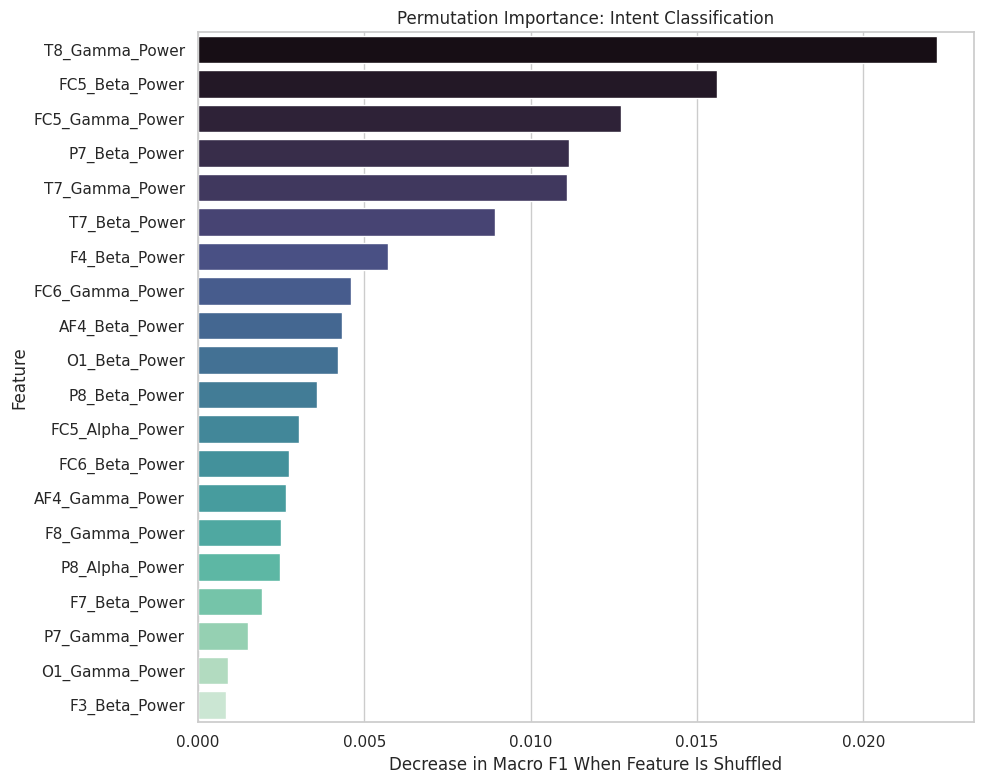

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=intent_importance_df.head(20),
    x="Importance_Mean",
    y="Feature",
    palette="mako",
)

plt.title("Permutation Importance: Intent Classification")
plt.xlabel("Decrease in Macro F1 When Feature Is Shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("Permutation_Importance_Intent_RF.png", dpi=300, bbox_inches="tight")
plt.show()


,Channel,Importance_Mean
6,FC5,0.031335
13,T8,0.016475
12,T7,0.012438
7,FC6,0.007972
10,P7,0.007243
8,O1,0.004757
11,P8,0.004489
5,F8,0.003265
1,AF4,0.002065
3,F4,0.000051


/tmp/ipykernel_8756/3032207552.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


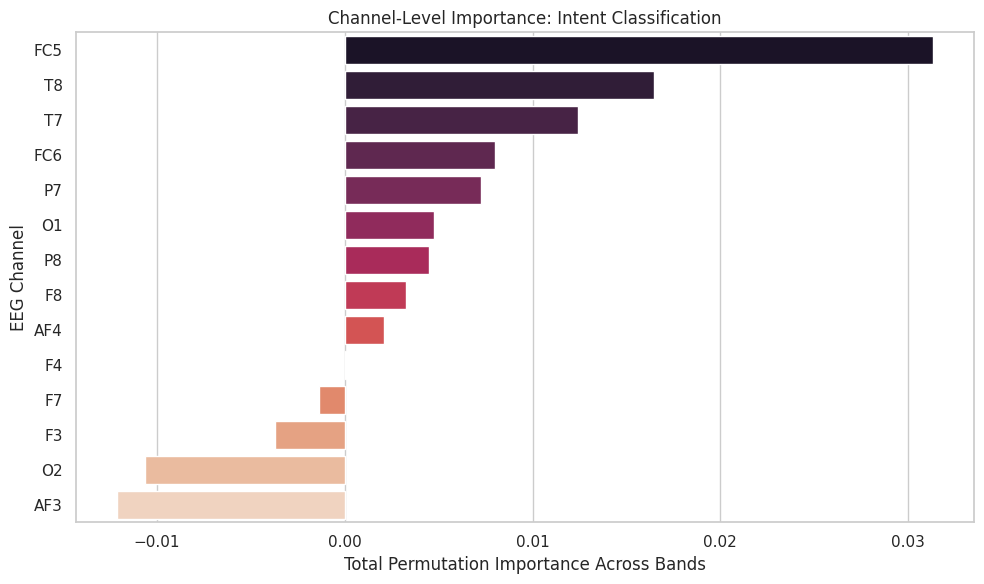

In [ ]:
channel_importance = intent_importance_df.copy()

channel_importance["Channel"] = (
    channel_importance["Feature"]
    .str.replace("_Alpha_Power", "", regex=False)
    .str.replace("_Beta_Power", "", regex=False)
    .str.replace("_Gamma_Power", "", regex=False)
)

channel_summary = (
    channel_importance
    .groupby("Channel", as_index=False)["Importance_Mean"]
    .sum()
    .sort_values("Importance_Mean", ascending=False)
)

display(channel_summary)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_summary,
    x="Importance_Mean",
    y="Channel",
    palette="rocket",
)

plt.title("Channel-Level Importance: Intent Classification")
plt.xlabel("Total Permutation Importance Across Bands")
plt.ylabel("EEG Channel")
plt.tight_layout()
plt.savefig("Channel_Importance_Intent_RF.png", dpi=300, bbox_inches="tight")
plt.show()


,Band,Importance_Mean
1,Beta,0.045301
2,Gamma,0.044646
0,Alpha,-0.027769


/tmp/ipykernel_8756/4011830795.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


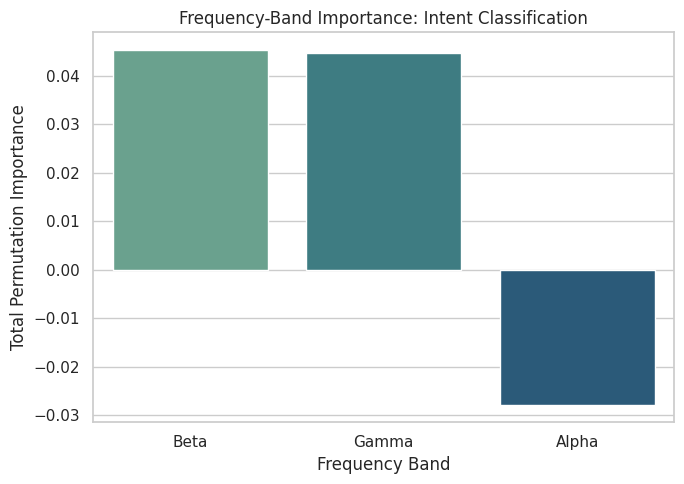

In [ ]:
band_importance = intent_importance_df.copy()

def extract_band(feature_name):
    if "_Alpha_Power" in feature_name:
        return "Alpha"
    if "_Beta_Power" in feature_name:
        return "Beta"
    if "_Gamma_Power" in feature_name:
        return "Gamma"
    return "Other"

band_importance["Band"] = band_importance["Feature"].apply(extract_band)

band_summary = (
    band_importance
    .groupby("Band", as_index=False)["Importance_Mean"]
    .sum()
    .sort_values("Importance_Mean", ascending=False)
)

display(band_summary)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=band_summary,
    x="Band",
    y="Importance_Mean",
    palette="crest",
)

plt.title("Frequency-Band Importance: Intent Classification")
plt.xlabel("Frequency Band")
plt.ylabel("Total Permutation Importance")
plt.tight_layout()
plt.savefig("Band_Importance_Intent_RF.png", dpi=300, bbox_inches="tight")
plt.show()


## Phase 5: Random Forest Intent Classifier Interpretability

The Random Forest intent classifier achieved 26.42% accuracy and 0.2541 macro F1 on a grouped holdout split containing unseen subjects. This is consistent with the earlier grouped cross-validation results and confirms that the classifier performs modestly above chance, but remains weak overall.

Permutation importance showed that the most useful features were primarily Beta and Gamma band-power features. The top individual feature was `T8_Gamma_Power`, followed by `FC5_Beta_Power`, `FC5_Gamma_Power`, `P7_Beta_Power`, and `T7_Gamma_Power`.

At the channel level, the strongest contributors were:

- `FC5`
- `T8`
- `T7`
- `FC6`
- `P7`

The occipital electrode `O1` contributed modestly, but `O2` had negative permutation importance in this holdout split. Therefore, the classifier did not strongly isolate the occipital visual cortex as originally hypothesized.

At the frequency-band level, Beta and Gamma features were most useful:

- Beta total importance: 0.0453
- Gamma total importance: 0.0446
- Alpha total importance: -0.0278

This suggests that task classification relied more on higher-frequency activity than Alpha-band power. However, because the classifier's overall performance was weak, these importance results should be treated as exploratory rather than definitive neuroscience evidence.


These results do not support the claim that the model learned a clean visual-cortex ssVEP decoder from broad-band features. Instead, the model relied on distributed temporal, frontocentral, and parietal features, especially in the Beta and Gamma bands. This pattern may reflect broad attentional, motor, or task-engagement differences rather than pure visual ssVEP activity.

A more biologically targeted ssVEP model would require extracting stimulus-frequency and harmonic power, especially from O1 and O2, rather than relying only on broad Alpha/Beta/Gamma bands.


Aging:
The original Age hypothesis could not be confirmed through Steady-State Time regression because the target was mostly task-defined and not a valid continuous cognitive-agility measure.

Gender:
Gender appeared important in the no-task Steady-State model, but that model failed to generalize, with R2 = -0.2307. Therefore, Gender importance should not be interpreted as a reliable predictor of cognitive speed. P100 proxy regression also failed, so Gender effects on P100 prediction were not supported.

Brain Regions:
The classifier did not heavily weight O1/O2 as dominant predictors. O1 contributed modestly, while O2 was not useful in the permutation analysis. This does not support the claim that the model isolated the visual cortex. Instead, importance was distributed across FC5, T8, T7, FC6, and P7.


**The pipeline worked. The broad-band feature set was not biologically specific enough.**